# **Neural-Network-based Approach**

In [ ]:
import os
import json
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import itertools
import matplotlib.patches as mpatches
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM,
                                          Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import torch
from fastai.text.all import *
from fastai.callback.tracker import CSVLogger
from sklearn.metrics import f1_score
from fastai.text.all import load_learner
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 80)

> **Gating Switch**: you can choose to load saved results or retrain from scratch.

In [ ]:
# False = load and display saved results (default, no training)
# True  = retrain from scratch
FORCE_RETRAIN = False
print(f"FORCE_RETRAIN = {FORCE_RETRAIN}")

FORCE_RETRAIN = False


> **Path Configuration**

In [ ]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ARTEMIS_Sentiment_Analysis'
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Data
DATASET_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'artemis_master_dataset.csv')

# Models
MODELS_DIR       = os.path.join(PROJECT_ROOT, 'models')
BILSTM_DIR       = os.path.join(MODELS_DIR, 'bilstm')
ULMFIT_MODEL_DIR = os.path.join(MODELS_DIR, 'ulmfit')

# Results
GRID_DIR   = os.path.join(PROJECT_ROOT, 'results', 'grid_search')
BILSTM_RES = os.path.join(PROJECT_ROOT, 'results', 'bilstm')
BILSTM_FIG = os.path.join(BILSTM_RES, 'figures')
ULMFIT_RES = os.path.join(PROJECT_ROOT, 'results', 'ulmfit')
ULMFIT_FIG = os.path.join(ULMFIT_RES, 'figures')

Mounted at /content/drive


## **1. Data Preparation**

### **1.1 Data Loading & Data Splitting**

The train, validation, and test partitions are loaded from pre-saved CSV files
(`data/splits/`) rather than being recomputed at runtime.

Why not just call `train_test_split` again? In principle, a fixed
`random_state=42` makes `train_test_split` deterministic. In practice, the
internal shuffling routine used by scikit-learn's stratified split has changed
across library versions: running the *same* code with the *same* seed on a
different scikit-learn version produces a *different* partition.

> **Note**: We confirmed
this empirically, recomputing the split in this environment placed 168 of the
994 test tweets differently from the original run that produced our trained
models and saved predictions.

This matters because every downstream artifact in this project, the trained models, the saved test-set probabilities (`probs_*.npy`), the confusion
matrices, was generated against
one specific partition. If the test set silently changed, the saved predictions
would no longer correspond to the right tweets, and all reported metrics would
be invalid.

To eliminate this fragility, we treat the data split as a fixed artifact
rather than a recomputed step: the exact partitions used during training are
stored as CSV files and loaded directly. This guarantees byte-identical
train/validation/test sets on any machine, regardless of installed library
versions. The split is loaded the same way whether or not the model is being
retrained, so a user who sets `FORCE_RETRAIN = True` trains on the *same* data
as the original run, keeping results directly comparable.

The original stratified 70/15/15 `train_test_split` logic (with
`random_state=42`) is preserved in the code as a fallback, used only if the
saved split files are absent. We acknowledge that loading fixed splits is not
the conventional approach; we adopt it here as a deliberate reproducibility
safeguard, since the saved model artifacts are the ground truth this notebook
is built to display.

In [ ]:
SPLITS_DIR = os.path.join(PROJECT_ROOT, 'data', 'splits')
splits_exist = all(os.path.exists(os.path.join(SPLITS_DIR, f))
                   for f in ['train_split.csv', 'val_split.csv', 'test_split.csv'])

if splits_exist:
    # Always prefer the fixed splits — even when retraining — so results stay
    # comparable to the original run regardless of library versions.
    train_df = pd.read_csv(os.path.join(SPLITS_DIR, 'train_split.csv'))
    val_df   = pd.read_csv(os.path.join(SPLITS_DIR, 'val_split.csv'))
    test_df  = pd.read_csv(os.path.join(SPLITS_DIR, 'test_split.csv'))

    X_train, y_train = train_df['text'].values, train_df['label'].values
    X_val,   y_val   = val_df['text'].values,   val_df['label'].values
    X_test,  y_test  = test_df['text'].values,  test_df['label'].values
    print("Splits loaded from data/splits/.")
else:
    # Fallback only if the saved splits are missing: recompute the original
    # stratified 70/15/15 split (may differ across sklearn versions).
    from sklearn.model_selection import train_test_split
    df = pd.read_csv(DATASET_PATH).dropna(subset=['cleaned_text', 'Sentiment_label'])
    X = df['cleaned_text'].values
    y = df['Sentiment_label'].values
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)
    print("Splits recomputed via train_test_split (saved splits not found).")

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Splits loaded from data/splits/.
Train: 4636, Val: 993, Test: 994


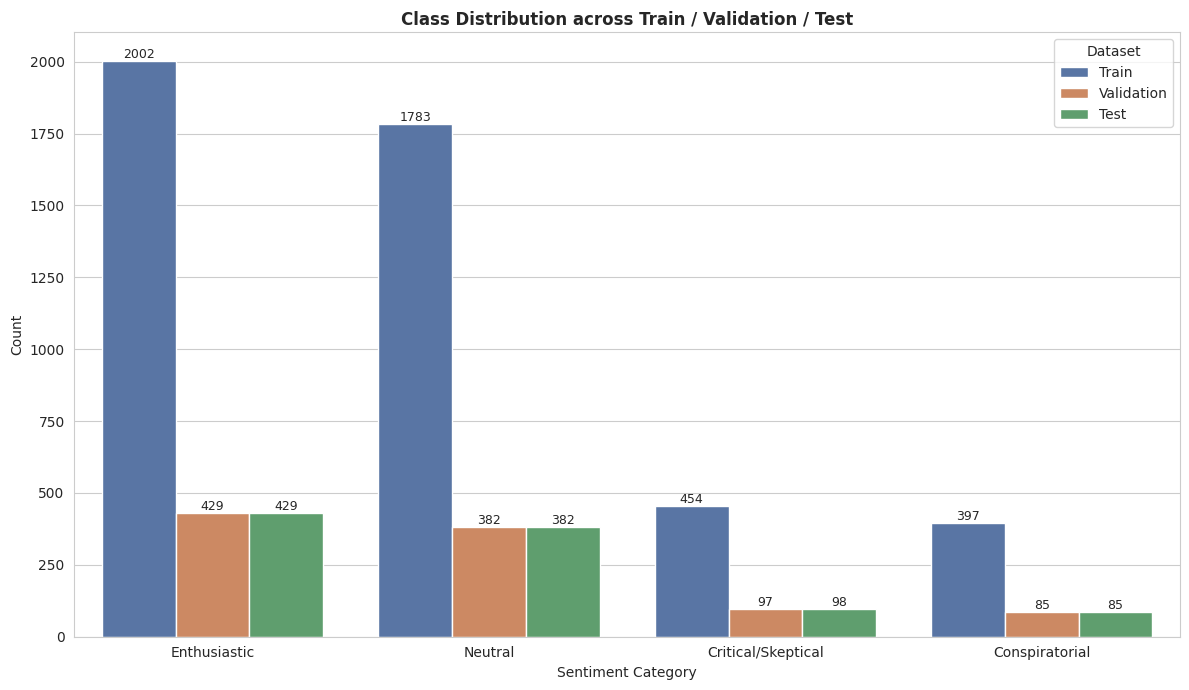

In [ ]:
train_counts = pd.Series(y_train).value_counts().rename('Train')
val_counts   = pd.Series(y_val).value_counts().rename('Validation')
test_counts  = pd.Series(y_test).value_counts().rename('Test')

df_counts = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0)
df_counts = df_counts.reset_index().rename(columns={'index': 'Sentiment'})
df_melted = df_counts.melt(id_vars='Sentiment', var_name='Dataset', value_name='Count')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='Sentiment', y='Count', hue='Dataset',
                 palette=['#4C72B0', '#DD8452', '#55A868'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9)

plt.title('Class Distribution across Train / Validation / Test', fontweight='bold')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Since Scikit-Learn's train_test_split function only divides a dataset into two subsets at a time, creating three distinct sets (Train, Validation, and Test) requires a two-step process.

First Split: We extract 15% of the entire dataset to serve as the held-out Test set. This leaves 85% of the original data in a temporary subset.

Second Split: We must extract the Validation set from this remaining 85%. Since we want the Validation set to represent 15% of the original total dataset, we calculate the proportion relative to the temporary subset: 15 / 85 is approximately 0.1764 (17.64%).

> **Note**: In both steps, we explicitly set `stratify` to the target labels. This guarantees that the original distribution of our four sentiment categories (*Enthusiastic*, *Neutral*, *Critical*, *Conspiratorial*) remains mathematically consistent across all three resulting datasets, preventing any single set from being heavily skewed.

 As we analyzed in the `02_exploratory_data_analysis` notebook, we can observe a significant class imbalance: Enthusiastic* or *Neutral* sentiments appear much more frequently than *Conspiratorial* and *Critical/Skeptical*.

The grouped bar chart above serves two purposes, which are:
* highlighting the overall class imbalance within the dataset and confirming the application of the `stratify` parameter;
* showing that the proportional distribution of each sentiment category is maintained across the Train, Validation, and Test sets.

While stratified splitting ensures consistent distributions across our data subsets, it does not solve the fundamental issue: the model will still encounter very few examples of the minority classes during training. To address this severe imbalance during the subsequent modeling phases (for both Neural-Network-based and Transformer-based approaches), we will implement the following strategies:

* By applying **Class Weights**, we instruct the model's Loss Function to heavily penalize misclassifications on rare classes compared to errors made on the majority classes. This forces the network to pay closer attention to the underrepresented categories.
* We avoid relying on Accuracy. If the majority of the tweets were *Neutral*, a model could obtain high accuracy simply by predicting *Neutral* for every single input. To ensure a fair evaluation, we use the **Macro F1-Score**. This metric calculates the performance for each class independently and then computes the unweighted mean, giving equal importance to every class regardless of its frequency in the dataset.

### **1.2 Label Encoder**

By default (`FORCE_RETRAIN = False`), the encoder fitted during the original training run is loaded from `label_encoder.pkl`, guaranteeing the class-to-index mapping is identical to the one used when the saved predictions were generated. When `FORCE_RETRAIN = True`, a fresh encoder is fitted on the training set (using `fit` on train only, then `transform` on validation and test, to prevent data leakage).


In [ ]:
encoder_path = os.path.join(MODELS_DIR, 'label_encoder.pkl')
if os.path.exists(encoder_path) and not FORCE_RETRAIN:
    with open(encoder_path, 'rb') as f:
        label_encoder = pickle.load(f)
    print("LabelEncoder loaded from saved file.")
else:
    label_encoder = LabelEncoder()
    label_encoder.fit(y_train)
    print("LabelEncoder re-fitted (FORCE_RETRAIN).")

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

target_names = list(label_encoder.classes_)
for cls, idx in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{cls}: {idx}")

LabelEncoder loaded from saved file.
Conspiratorial: 0
Critical/Skeptical: 1
Enthusiastic: 2
Neutral: 3


## **2. Text Processing Pipeline**



### **2.1 Tokenizer and Padding**

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 12000
MAX_LEN = 60
TRUNC_TYPE = 'post'
PADDING_TYPE = 'post'

tokenizer_path = os.path.join(MODELS_DIR, 'tokenizer.pkl')
if os.path.exists(tokenizer_path) and not FORCE_RETRAIN:
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    print("Tokenizer loaded from saved file.")
else:
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)
    print("Tokenizer re-fitted (FORCE_RETRAIN).")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding=PADDING_TYPE, truncating=TRUNC_TYPE)

print(f"Train tensor: {X_train_pad.shape}")
print(f"Val tensor:   {X_val_pad.shape}")
print(f"Test tensor:  {X_test_pad.shape}")

Tokenizer loaded from saved file.
Train tensor: (4636, 60)
Val tensor:   (993, 60)
Test tensor:  (994, 60)


#### **2.1.1 Tokenization**

We initialize a Keras Tokenizer with a maximum vocabulary size (`VOCAB_SIZE`) of 12,000 words. This limit ensures the model focuses on the most frequent and meaningful terms across the corpus, filtering out extremely rare words or typos that could act as statistical noise. Any word outside this top 12,000, or any completely unseen word encountered in the future, is replaced by the predefined Out-Of-Vocabulary token (`<OOV>`).

Crucially, to prevent data leakage, we strictly call the `fit_on_texts` method only on the training set (`X_train`). The model must not learn or build its vocabulary based on the validation or test sets.

#### **2.1.2 Sequence Padding and Truncating**

Neural network architectures expect input batches of a uniform size, but our tweets naturally vary in length. To resolve this, we standardize every sequence to our chosen `MAX_LEN` of 60 tokens:

* **Padding:** If a tweet has fewer than 60 tokens, we add zeros to the end of the sequence (`padding='post'`).
* **Truncating:** If a tweet exceeds 60 tokens, we cut off the excess tokens at the end (`truncating='post'`).

#### **2.1.3 Understanding the Output Tensors**

The output confirms that our text has been successfully converted into uniform 2D numerical matrices. For instance, the Training tensor shape is `(4636, 60)`. This means the training set is now a matrix containing 4,636 rows (one for each tweet) and exactly 60 columns (the integer representation of the tokens). This  data is now ready to be passed into the network's Embedding layer.



### **2.2 `MAX_LEN` Threshold Justifycation**

-----------------------------------
 TOKEN LENGTH STATISTICS
-----------------------------------
Mean (Average) Length : 25.98 tokens
Median Length         : 22.00 tokens
Minimum Length        : 2 tokens
Maximum Length        : 285 tokens
-----------------------------------


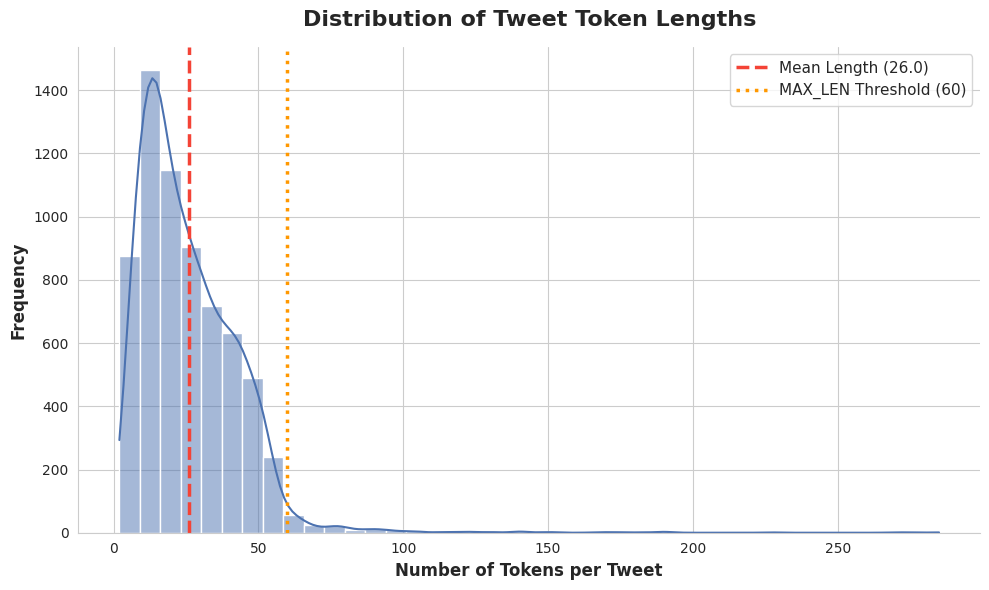

In [ ]:
all_sequences = X_train_seq + X_val_seq + X_test_seq
tweet_lengths = [len(seq) for seq in all_sequences]

mean_length   = np.mean(tweet_lengths)
median_length = np.median(tweet_lengths)
min_length    = np.min(tweet_lengths)
max_length    = np.max(tweet_lengths)

print("-" * 35)
print(" TOKEN LENGTH STATISTICS")
print("-" * 35)
print(f"Mean (Average) Length : {mean_length:.2f} tokens")
print(f"Median Length         : {median_length:.2f} tokens")
print(f"Minimum Length        : {min_length} tokens")
print(f"Maximum Length        : {max_length} tokens")
print("-" * 35)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(tweet_lengths, bins=40, kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(mean_length, color='#F44336', linestyle='dashed', linewidth=2.5,
            label=f'Mean Length ({mean_length:.1f})')
plt.axvline(MAX_LEN, color='#FF9800', linestyle='dotted', linewidth=2.5,
            label=f'MAX_LEN Threshold ({MAX_LEN})')
plt.title('Distribution of Tweet Token Lengths', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Tokens per Tweet', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Total tweets: 6623
Tweets with more than 60 tokens: 139 (2.10%)



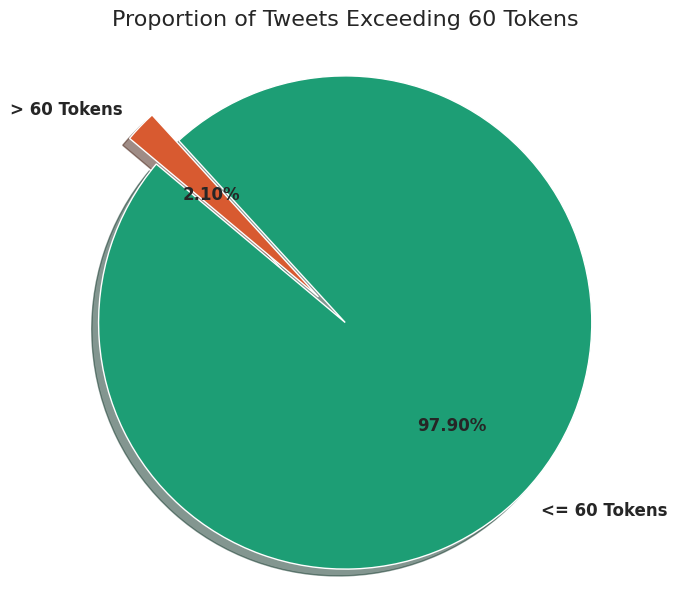

In [ ]:
long_tweets   = sum(1 for length in tweet_lengths if length > MAX_LEN)
normal_tweets = len(tweet_lengths) - long_tweets
percent_long  = (long_tweets / len(tweet_lengths)) * 100

print(f"Total tweets: {len(tweet_lengths)}")
print(f"Tweets with more than {MAX_LEN} tokens: {long_tweets} ({percent_long:.2f}%)\n")

labels  = [f'<= {MAX_LEN} Tokens', f'> {MAX_LEN} Tokens']
sizes   = [normal_tweets, long_tweets]
colors  = ['#1D9E75', '#D85A30']
explode = (0, 0.15)

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.2f%%', shadow=True, startangle=140,
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title(f'Proportion of Tweets Exceeding {MAX_LEN} Tokens', fontsize=16, pad=20)
plt.axis('equal')
plt.show()

As demonstrated by the statistical analysis and the distribution plots above, the average length of a tweet in our dataset is approximately 26 tokens, with a median of 22. While there are a few extreme outliers (reaching up to 285 tokens), the vast majority of our text is relatively concise.

This empirical evidence directly informs our decision to set the `MAX_LEN` parameter to 60.

By analyzing the data, we discovered that only a tiny fraction of the tweets, 139 out of 6,623, which corresponds to exactly **2.10%** of the entire dataset, exceed this 60-token limit.

This represents an engineering trade-off:

* **Computational Efficiency:** It prevents our neural network from wasting memory and training time processing excessive zero-padding for the remaining 97.9% of the shorter tweets.
* **Information Retention:** Truncating only 2.10% of the longest texts ensures that we do not sacrifice any meaningful, sentiment-bearing information across the vast majority of our corpus.

## **3. Loss Function**

### **3.1 Class Weights Computation**

As anticipated, while the stratified split preserves the real-world distribution of the
Artemis II tweets, the severe class imbalance remains a critical hurdle for the network.
We now implement the countermeasure discussed earlier: a class-weighted loss.

Rather than assigning arbitrary penalties by hand, we use the `compute_class_weight`
utility from scikit-learn with its `balanced` heuristic. For each class $j$, this computes
a weight inversely proportional to that class's frequency in the training set:

$$w_j = \frac{n_{\text{samples}}}{n_{\text{classes}} \cdot n_j}$$

where $n_{\text{samples}}$ is the total number of training examples, $n_{\text{classes}} = 4$
is the number of sentiment classes, and $n_j$ is the number of training examples in class
$j$.

A class with exactly its fair share of the data ($n_j = n_{\text{samples}} /
n_{\text{classes}}$) receives a weight of 1.0; under-represented classes receive weights above 1.0, and the over-represented majority classes
receive weights below 1.0.

The resulting dictionary is passed directly to Keras through the `class_weight` parameter
of the `fit` method. During training, each sample's contribution to the loss is scaled by
its class weight, so that errors on the rare *Critical* and *Conspiratorial* tweets count
more heavily than errors on the majority classes. This pushes the optimizer to learn the
minority classes rather than defaulting to the majority.

In [ ]:
classes_array = np.unique(y_train_encoded)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes_array,
                               y=y_train_encoded)
class_weights_dict = dict(zip(classes_array, weights))

print("--- Class Weights ---")
for class_idx, weight in class_weights_dict.items():
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"{class_name} ({class_idx}): Weight = {weight:.4f}")

--- Class Weights ---
Conspiratorial (0): Weight = 2.9194
Critical/Skeptical (1): Weight = 2.5529
Enthusiastic (2): Weight = 0.5789
Neutral (3): Weight = 0.6500


The printed output illustrates the imbalanced distribution of the Artemis II dataset discussed during the exploratory data analysis. Because the *Enthusiastic* and *Neutral* tweets represent the vast majority of our corpus, the balancing algorithm has assigned them fractional weights of approximately 0.58 and 0.65. This intentionally reduces their influence on the loss function.

Conversely, the model is instructed to heavily penalize errors made on the minority classes. The *Critical/Skeptical* category receives a weight multiplier of 2.55, while the rarest class, *Conspiratorial*, receives the highest weight of nearly 2.92. In practice, this means the neural network will incur a penalty almost three times larger for misclassifying a *Conspiratorial* tweet than it would for a standard text.

This scaling effectively levels the playing field, ensuring the model focuses adequately on the nuanced vocabulary of the rarer, more critical narratives instead of taking the easy route of always predicting the majority sentiments.

## **4. Pre-Trained Word Embeddings (GloVe Twitter)**

### **4.1 GloVe Introduction**

In [ ]:
import urllib.request
import zipfile

EMBEDDINGS_DIR = os.path.join(MODELS_DIR, 'embeddings')
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

EMBED_DIM = 100
glove_file_name = f'glove.twitter.27B.{EMBED_DIM}d.txt'
glove_path = os.path.join(EMBEDDINGS_DIR, glove_file_name)
glove_zip_path = os.path.join(EMBEDDINGS_DIR, 'glove.twitter.27B.zip')

# Download only if the file is genuinely absent (won't trigger on your setup)
if not os.path.exists(glove_path):
    print(f'{glove_file_name} not found. Downloading GloVe Twitter (~1.4 GB)...')
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.twitter.27B.zip', glove_zip_path)
    with zipfile.ZipFile(glove_zip_path, 'r') as z:
        z.extract(glove_file_name, path=EMBEDDINGS_DIR)
    os.remove(glove_zip_path)
    print('Download and extraction complete.')
else:
    print(f'{glove_file_name} found. Skipping download.')

# Load vectors
embeddings_index = {}
all_embs = []
print('Loading GloVe vectors into memory...')
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        if len(coefs) == EMBED_DIM:
            embeddings_index[word] = coefs
            all_embs.append(coefs)
print(f'Loaded {len(embeddings_index)} GloVe word vectors.')

all_embs = np.vstack(all_embs)
emb_mean, emb_std = all_embs.mean(), all_embs.std()

# Build embedding matrix (OOV words get GloVe-like random vectors)
np.random.seed(42)
embedding_matrix = np.random.normal(emb_mean, emb_std, (VOCAB_SIZE, EMBED_DIM))
embedding_matrix[0] = 0  # padding index

words_found = 0
for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        words_found += 1

print(f'Initial coverage: {words_found}/{VOCAB_SIZE} words.')

glove.twitter.27B.100d.txt found. Skipping download.
Loading GloVe vectors into memory...
Loaded 1193513 GloVe word vectors.
Initial coverage: 7580/12000 words.


Before feeding our tokenized tweets into the neural network, we must convert them into meaningful numerical representations. While a standard Keras Embedding layer can learn these representations from scratch during training, doing so effectively requires a massive corpus. To accelerate learning and improve performance, we rely on the pre-trained word embeddings.

`GloVe` - Global Vectors for Word Representation - is an algorithm designed to map words into a dense, multi-dimensional vector space. In this space, the geometric distance and direction between word vectors mathematically capture their semantic relationships and linguistic context.

Crucially, we specifically opted for the `GloVe Twitter` version rather than the standard versions. Standard embeddings are trained on highly formal text, which severely mismatches the informal, noisy nature of our Artemis II dataset.
By utilizing the GloVe model pre-trained specifically on a massive corpus of 2 billion tweets, we provide our network with a native understanding of social media language right out of the box. This choice wants to minimizes the Out-Of-Vocabulary rate and establishes a far more accurate semantic baseline for our sentiment classification.

Furthermore, to optimize the embedding matrix, instead of padding unmapped or unknown words with pure zeros, which can negatively impact the network's gradient updates, we initialize these out-of-vocabulary words with random vectors drawn from the exact same statistical distribution (mean and standard deviation) as the known GloVe vectors.

It is important to note how these embeddings are used during training. Rather than freezing the embedding layer, we allow it to remain **trainable**, so that the GloVe Twitter vectors act as an informed *initialization* that is then fine-tuned on the Artemis II corpus. This choice suits a small, domain-specific dataset: it lets the embeddings adapt to the particular usage of
space-related and mission-specific terms, including the out-of-vocabulary words initialized
randomly, while still starting from a strong, pre-trained semantic foundation rather than from
scratch. In other words, GloVe provides the starting point and the general-language grounding,
and fine-tuning specialises the representations to the vocabulary and sentiment patterns of this
specific corpus.

### **4.2 Glove Twitter Embedding Coverage Check**

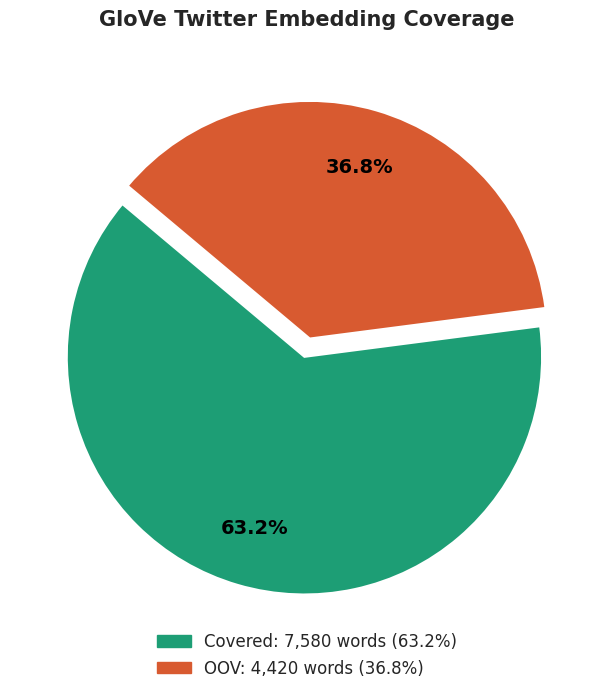

In [ ]:
oov_count = VOCAB_SIZE - words_found
coverage = (words_found / VOCAB_SIZE) * 100
sizes  = [words_found, oov_count]
colors = ['#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes, explode=(0.04, 0.04), labels=None, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    pctdistance=0.75, textprops=dict(fontsize=13)
)
for at in autotexts:
    at.set_color('black'); at.set_fontweight('bold'); at.set_fontsize(14)

legend_patches = [
    mpatches.Patch(color=colors[0], label=f'Covered: {words_found:,} words ({coverage:.1f}%)'),
    mpatches.Patch(color=colors[1], label=f'OOV: {oov_count:,} words ({100 - coverage:.1f}%)')
]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=12, frameon=False)
ax.set_title('GloVe Twitter Embedding Coverage', fontsize=15, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()

The generated pie chart provides a clear visual breakdown of our embedding mapping success. Out of our established vocabulary limit of 12,000 words, we successfully matched 7,580 words, achieving a solid 63.2% coverage against the pre-trained GloVe Twitter dictionary.

Achieving over 60% coverage is considered a strong and highly effective baseline when dealing with noisy social media datasets. It guarantees that the foundational English language, common internet slang, and general sentiment indicators are mathematically grounded in a robust semantic space at initialization.

The remaining 4,420 words, representing 36.8% of the vocabulary, are classified as Out-Of-Vocabulary. In the context of our specific dataset, these are predominantly domain-specific entities related to the space mission.

Crucially, this 36.8% OOV rate is not a loss of data. Because of the initialization technique in the previous step, drawing random vectors from the GloVe statistical distribution rather than using static zeros, we have created an optimal starting condition.

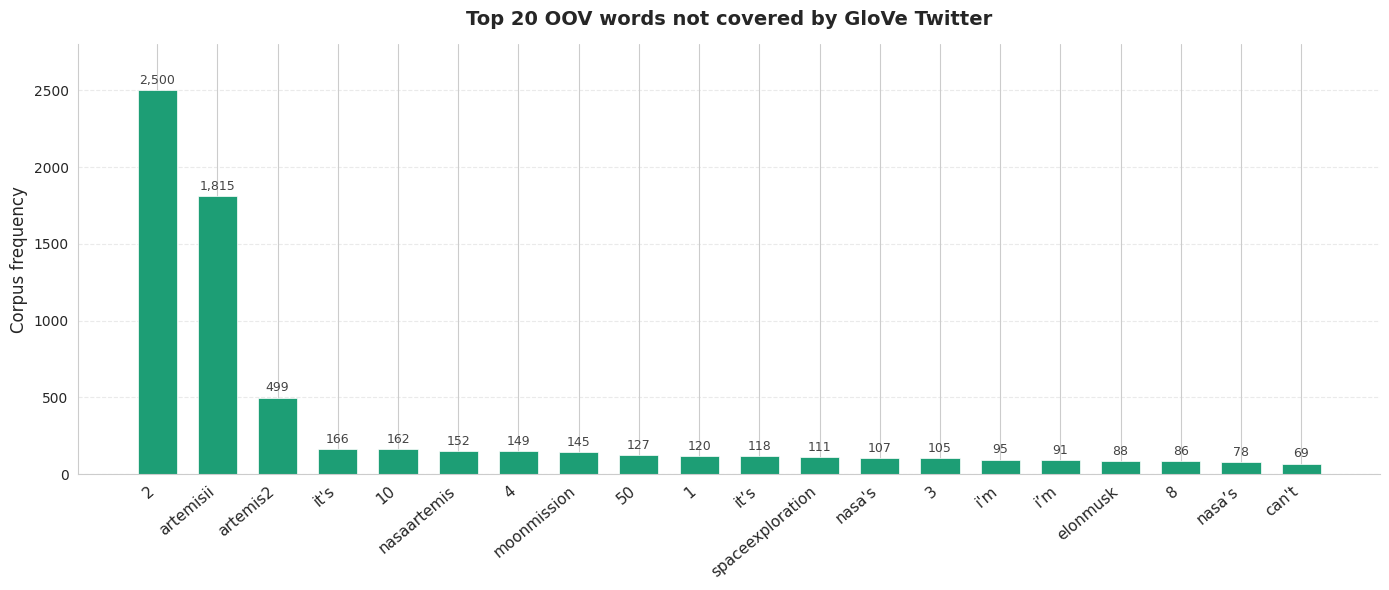

In [ ]:
oov_words = []
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if embeddings_index.get(word) is None:
        oov_words.append((word, tokenizer.word_counts.get(word, 0)))

TOP_N = 20
oov_sorted = sorted(oov_words, key=lambda x: x[1], reverse=True)[:TOP_N]
words_plot, freqs_plot = zip(*oov_sorted)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(words_plot)), freqs_plot,
              color='#1D9E75', edgecolor='white', linewidth=0.5, width=0.65)
for bar, freq in zip(bars, freqs_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(freqs_plot) * 0.008,
            f'{freq:,}', ha='center', va='bottom', fontsize=9, color='#444')
ax.set_xticks(range(len(words_plot)))
ax.set_xticklabels(words_plot, rotation=40, ha='right', fontsize=11)
ax.set_ylabel('Corpus frequency', fontsize=12)
ax.set_title(f'Top {TOP_N} OOV words not covered by GloVe Twitter', fontsize=14, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, max(freqs_plot) * 1.12)
plt.tight_layout()
plt.show()

Analyzing the generated bar chart of the top 20 Out-Of-Vocabulary words reveals a fascinating mix of linguistic patterns in our dataset, which can be grouped into three distinct categories.

First, we observe raw numbers such as 2, 10, 50, 1, 3, and 8. Second, as expected, we see highly domain-specific terms and collapsed hashtags such as artemisii, artemis2, nasaartemis, spaceexploration, and elonmusk. These are natural OOV candidates; they are specific to our modern space mission context and will be learned dynamically by our network thanks to the advanced random initialization we implemented earlier.

However, the third category exposes a crucial typographic artifact: the presence, and notable repetition, of extremely common English contractions and possessives, such as it's, I'm, nasa's, and can't. The fact that terms like it's and I'm appear multiple times as separate distinct entries in the top 20 strongly indicates that users are typing different Unicode apostrophes on their devices. Our tokenizer treats these variations as entirely different words.

Because the GloVe Twitter dictionary is highly specific about punctuation and standardization, these contractions fail to map to their correct pre-trained vectors. Leaving this unaddressed would artificially inflate our OOV rate and deprive the neural network of the foundational semantic meaning of these highly frequent words. Therefore, in the subsequent step, we will implement a targeted apostrophe and contraction patch. This script will dynamically map these varying Unicode characters to the standardized formats recognized by GloVe Twitter, rescuing these words from the OOV and boosting our actual embedding coverage.

### **4.3 GloVe Embeddings Matrix Fix**



In [ ]:
variants = ["can't", "can\u2019t", "cant", "i'm", "i\u2019t", "im"]
for v in variants:
    vec = embeddings_index.get(v)
    print(f"'{v}' -> {'FOUND' if vec is not None else 'NOT FOUND'} in GloVe")

'can't' -> NOT FOUND in GloVe
'can’t' -> NOT FOUND in GloVe
'cant' -> FOUND in GloVe
'i'm' -> NOT FOUND in GloVe
'i’t' -> NOT FOUND in GloVe
'im' -> FOUND in GloVe


As demonstrated by our queries for "can't" and "i'm", the GloVe Twitter model natively indexes most contractions by stripping their punctuation entirely (e.g., "cant", "im"). This mismatch is the primary reason our tokenizer failed to map highly frequent terms, artificially inflating our OOV rate.

To resolve this, we engineered a custom contraction patch. We defined a mapping of common English contractions and generated variations across six different Unicode apostrophe characters commonly found in social media text. By dynamically linking these irregular tokens to their corresponding clean vectors in the GloVe index, the automated patch successfully integrated 89 unique contraction variants.

After applying this fix and rebuilding the embedding matrix, our most frequent missing words were rescued, pushing our definitive embedding coverage to 63.4%. With this optimized and grammatically robust semantic foundation, our embedding layer is initialized and ready for the Bidirectional LSTM training phase.

In [ ]:
CONTRACTION_MAP = {
    "can't": "cant", "won't": "wont", "don't": "dont",
    "didn't": "didnt", "doesn't": "doesnt", "isn't": "isnt",
    "aren't": "arent", "wasn't": "wasnt", "it's": "its",
    "i'm": "im", "i've": "ive", "i'll": "ill",
    "you're": "youre", "they're": "theyre", "that's": "thats",
}
APOSTROPHE_VARIANTS = ["\u0027", "\u2019", "\u2018", "\u0060", "\u00B4", "\u02BC"]

patched = 0
for contraction, clean in CONTRACTION_MAP.items():
    if clean not in embeddings_index:
        continue
    for variant in APOSTROPHE_VARIANTS:
        contraction_variant = contraction.replace("'", variant)
        if contraction_variant not in embeddings_index:
            embeddings_index[contraction_variant] = embeddings_index[clean]
            patched += 1

print(f"Contraction patch applied: {patched} new entries added.")

Contraction patch applied: 89 new entries added.


In [ ]:
np.random.seed(42)
embedding_matrix = np.random.normal(emb_mean, emb_std, (VOCAB_SIZE, EMBED_DIM))
embedding_matrix[0] = 0

words_found = 0
for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        words_found += 1

coverage = (words_found / VOCAB_SIZE) * 100
oov_count = VOCAB_SIZE - words_found
print(f'GloVe coverage after patch: {words_found}/{VOCAB_SIZE} words ({coverage:.1f}%)')

GloVe coverage after patch: 7611/12000 words (63.4%)


### **4.3 Fixed GloVe Embeddings Matrix Check**



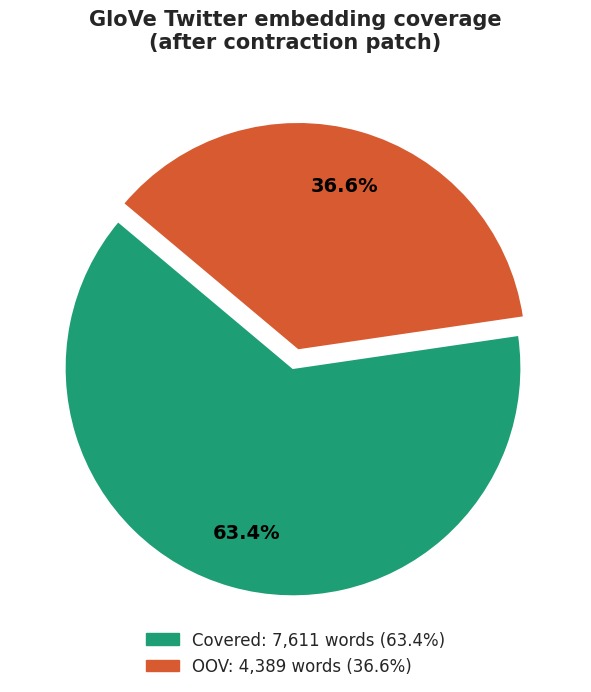

In [ ]:
labels = ['Covered by GloVe', 'Not covered (OOV)']
sizes  = [words_found, oov_count]
colors = ['#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes, explode=(0.04, 0.04), labels=None, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    pctdistance=0.75, textprops=dict(fontsize=13)
)
for at in autotexts:
    at.set_color('black'); at.set_fontweight('bold'); at.set_fontsize(14)

legend_patches = [
    mpatches.Patch(color=colors[0], label=f'Covered: {words_found:,} words ({coverage:.1f}%)'),
    mpatches.Patch(color=colors[1], label=f'OOV: {oov_count:,} words ({100 - coverage:.1f}%)')
]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=12, frameon=False)
ax.set_title('GloVe Twitter embedding coverage\n(after contraction patch)',
             fontsize=15, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()

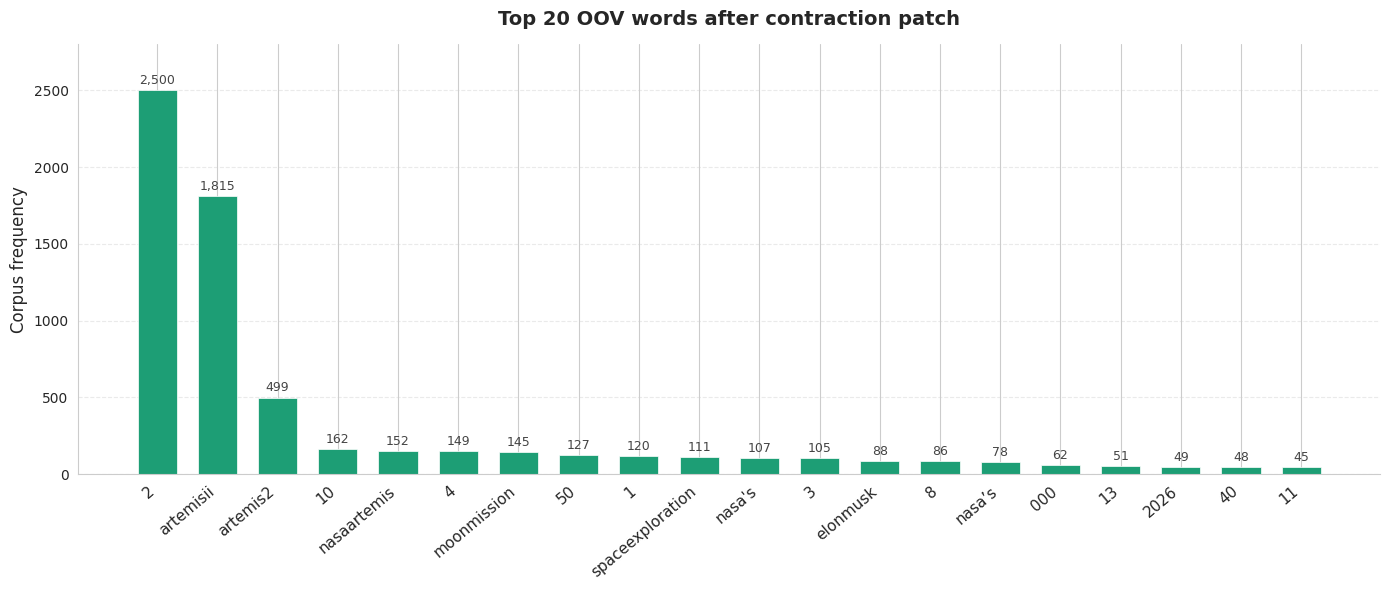

In [ ]:
oov_words = []
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if embeddings_index.get(word) is None:
        oov_words.append((word, tokenizer.word_counts.get(word, 0)))

TOP_N = 20
oov_sorted = sorted(oov_words, key=lambda x: x[1], reverse=True)[:TOP_N]
words_plot, freqs_plot = zip(*oov_sorted)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(words_plot)), freqs_plot,
              color='#1D9E75', edgecolor='white', linewidth=0.5, width=0.65)
for bar, freq in zip(bars, freqs_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(freqs_plot) * 0.008,
            f'{freq:,}', ha='center', va='bottom', fontsize=9, color='#444')
ax.set_xticks(range(len(words_plot)))
ax.set_xticklabels(words_plot, rotation=40, ha='right', fontsize=11)
ax.set_ylabel('Corpus frequency', fontsize=12)
ax.set_title(f'Top {TOP_N} OOV words after contraction patch', fontsize=14, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, max(freqs_plot) * 1.12)
plt.tight_layout()
plt.show()

The updated visualizations confirm the success of our targeted contraction patch. Looking at the new pie chart, our embedding coverage has stabilized at 63.4%, successfully mapping 7,611 words. While the overall percentage increase might appear modest, the qualitative improvement is immense because we successfully rescued highly frequent words that are critical for sentence syntax and sentiment expression.

This improvement is clearly demonstrated in the revised bar chart of the top 20 Out-Of-Vocabulary words. The disruptive typographic artifacts and common English contractions have been entirely eradicated from the top ranks. The remaining unmapped words now perfectly reflect the expected profile of a highly specialized dataset. The list consists almost exclusively of numerical values, such as 2, 2026, 50, and 10, alongside domain-specific concatenated terms and hashtags like artemisii, nasaartemis, spaceexploration, and elonmusk.

With the typographic noise effectively filtered out, our embedding matrix is now highly optimized. The BiLSTM network will rely on the robust GloVe vectors for foundational language comprehension, while seamlessly learning the specific contextual weights for these remaining mission-centric terms during the active training phase.

## **5. Bi-LSTM**

### **5.1 Grid Seacrh for Hyperparameters Fine-Tuning**

In [ ]:
tf.random.set_seed(SEED)
print(f"TensorFlow seed set to {SEED}.")

TensorFlow seed set to 42.


We selected a **Bidirectional Long Short-Term Memory** architecture (BiLSTM) as the first Neural-Network-based approach.

A standard recurrent neural network (RNN) processes a sentence token by
token, passing a hidden state forward at each step. In principle this lets it model
context, but in practice plain RNNs struggle with long sequences: as the gap between
relevant words grows, the gradient signal tends to vanish, and the network "forgets"
earlier context. The **LSTM** addresses this with a dedicated *memory cell* and a set of
*gates* (input, forget, and output) that regulate what information is added to, retained
in, or read from that cell at each step. This gating mechanism lets the network preserve
relevant context over longer spans, useful for tweets where the sentiment-bearing cue
and the entity it refers to may be several words apart.

A unidirectional LSTM reads strictly left to right, so at any
point it has only seen the preceding words. A bidirectional LSTM runs two LSTMs in
parallel, one forward, one backwardand, combines their states, so each token is
interpreted using both its left and right context. This is particularly helpful for the
nuanced sentiment, sarcasm, and domain-specific phrasing in the Artemis II corpus, where
the meaning of a word often depends on what follows it as much as what precedes it.

To maximize predictive performance, we do not rely on a single static architecture. Instead, we
conduct a systematic grid search over hyperparameter combinations, including the number of LSTM
units, dropout rates, and learning rates. Each configuration is trained for a maximum of 7
epochs, with the previously computed class weights injected into the training loop and the
validation metrics monitored at every epoch.

To control overfitting, a real risk given the small size of the dataset, the architecture
applies regularization at three different points, each targeting a distinct stage of information
flow:

* **`SpatialDropout1D`** is applied to the embedding output: rather than dropping individual
values, it drops entire embedding channels across the sequence, which is more effective for word
vectors whose dimensions are strongly correlated.

* **Recurrent dropout** is applied inside the
LSTM, regularizing the recurrent connections that carry the hidden state across time steps.


* A standard **`Dropout`** layer is applied before the output layer, regularizing the
final classification stage.

The grid search explores the rates of the first two (`recurrent_dropout` and `spatial_dropout`)(0.2 and 0.4, for both),
while the dense dropout is kept fixed.

> **Note**: enabling `recurrent_dropout` prevents Keras from
using the optimized cuDNN LSTM kernel, making training slower, an accepted trade-off for the
additional regularization of the recurrent state.

The grid search ranks configurations by validation **macro F1**, since that is the metric of interest for this imbalanced task and the most direct measure
of how well a configuration handles all four classes. Within the extended 20-epoch training,
however, the best epoch of each run is selected by validation **loss** (via `restore_best_weights`).
The two criteria serve different purposes: macro F1 identifies which configurations are most
promising, while validation loss provides a more stable, less noisy signal for choosing the best
*epoch* within a run, since macro F1 can fluctuate sharply between epochs on a small validation
set whereas validation loss decreases more smoothly.

> **Note**: By default (`FORCE_RETRAIN = False`) this cell loads
the saved results from `grid_search_results.json` and displays the top
configurations: no training is performed. The complete 16-combination search
code is preserved in the `else` branch and runs only when `FORCE_RETRAIN = True`
(which requires a GPU and the GloVe embedding matrix built above). In that case
it regenerates and overwrites `grid_search_results.json` and
`full_training_candidates.json`.

In [ ]:
grid_results_path = os.path.join(GRID_DIR, 'grid_search_results.json')
candidates_path   = os.path.join(GRID_DIR, 'full_training_candidates.json')

DENSE_DROPOUT       = 0.5
BATCH_SIZE          = 32
EMBEDDING_TRAINABLE = True

if os.path.exists(grid_results_path) and not FORCE_RETRAIN:
    results_df = pd.read_json(grid_results_path).sort_values(
        'val_f1_macro', ascending=False).reset_index(drop=True)
    print("Grid search results loaded from saved file.\n")

    print('--- Top 5 configurations (by val F1 macro) ---')
    print(results_df.head(5).to_string(index=False))

    best_lr_001  = results_df[results_df['learning_rate'] == 0.001].head(2)
    best_lr_0005 = results_df[results_df['learning_rate'] == 0.0005].head(2)

    print('\n--- Best 2 configurations with lr=0.001 ---')
    print(best_lr_001.to_string(index=False))

    print('\n--- Best 2 configurations with lr=0.0005 ---')
    print(best_lr_0005.to_string(index=False))

    # Final candidates: prefer the saved file if present, else derive from results
    if os.path.exists(candidates_path):
        candidates_preview = pd.read_json(candidates_path)
    else:
        candidates_preview = (pd.concat([best_lr_001, best_lr_0005])
                              .drop_duplicates()
                              .sort_values('val_f1_macro', ascending=False)
                              .reset_index(drop=True))

    print('\n--- Final candidates for full training ---')
    print(candidates_preview.to_string(index=False))
else:

    MAX_EPOCHS = 7
    param_grid = {
        'spatial_dropout':   [0.2, 0.4],
        'recurrent_dropout': [0.2, 0.4],
        'lstm_units':        [16, 32],
        'learning_rate':     [0.001, 0.0005],
    }
    keys = list(param_grid.keys())
    combinations = list(itertools.product(*param_grid.values()))
    print(f'Total combinations: {len(combinations)}')

    class F1ScoreCallback(Callback):
        def __init__(self, val_data):
            super().__init__(); self.X_val, self.y_val = val_data
        def on_epoch_end(self, epoch, logs=None):
            y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
            f1 = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
            logs['val_f1_macro'] = f1
            print(f"  Epoch {epoch+1} | loss: {logs['loss']:.4f} | "
                  f"val_loss: {logs['val_loss']:.4f} | val_f1_macro: {f1:.4f}")

    results = []
    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f'\n[{i+1}/{len(combinations)}] {params}')
        model = Sequential([
            Input(shape=(MAX_LEN,)),
            Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                      trainable=EMBEDDING_TRAINABLE),
            SpatialDropout1D(params['spatial_dropout']),
            Bidirectional(LSTM(params['lstm_units'], return_sequences=False,
                               recurrent_dropout=params['recurrent_dropout'])),
            Dropout(DENSE_DROPOUT),
            Dense(4, activation='softmax')
        ])
        model.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                      loss='sparse_categorical_crossentropy', metrics=[])
        early = EarlyStopping(monitor='val_loss', patience=3,
                              restore_best_weights=True, verbose=0)
        history = model.fit(X_train_pad, y_train_encoded,
                            validation_data=(X_val_pad, y_val_encoded),
                            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                            class_weight=class_weights_dict,
                            callbacks=[F1ScoreCallback((X_val_pad, y_val_encoded)), early],
                            verbose=0)
        y_pred = np.argmax(model.predict(X_val_pad, verbose=0), axis=1)
        results.append({**params,
                        'val_f1_macro': round(f1_score(y_val_encoded, y_pred, average='macro', zero_division=0), 4),
                        'best_val_loss': round(min(history.history['val_loss']), 4),
                        'epochs_run': len(history.history['val_loss'])})

    results_df = pd.DataFrame(results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
    os.makedirs(GRID_DIR, exist_ok=True)
    results_df.to_json(grid_results_path, orient='records', indent=2)

    best_001  = results_df[results_df['learning_rate'] == 0.001].head(2)
    best_0005 = results_df[results_df['learning_rate'] == 0.0005].head(2)
    cand = pd.concat([best_001, best_0005]).drop_duplicates().sort_values(
        'val_f1_macro', ascending=False).reset_index(drop=True)
    cand.to_json(candidates_path, orient='records', indent=2)
    print("\n--- Top 5 configurations ---")
    print(results_df.head(5).to_string(index=False))

Grid search results loaded from saved file.

--- Top 5 configurations (by val F1 macro) ---
 spatial_dropout  recurrent_dropout  lstm_units  learning_rate  val_f1_macro  best_val_loss  epochs_run
             0.2                0.4          32         0.0010        0.6048         0.8768           7
             0.2                0.4          16         0.0010        0.5855         0.8595           7
             0.2                0.2          16         0.0010        0.5745         0.9747           7
             0.2                0.2          32         0.0010        0.5711         0.9403           7
             0.2                0.4          32         0.0005        0.5676         0.9151           7

--- Best 2 configurations with lr=0.001 ---
 spatial_dropout  recurrent_dropout  lstm_units  learning_rate  val_f1_macro  best_val_loss  epochs_run
             0.2                0.4          32          0.001        0.6048         0.8768           7
             0.2               

In [ ]:
candidates = pd.read_json(candidates_path)

The results from the grid search provide useful insight into how the BiLSTM architecture
interacts with the weighted, imbalanced dataset.

The models using the higher learning rate of 1e-3 occupy the top two positions, with
Macro F1-Scores around 0.60. However, the epoch-by-epoch loss trajectories show that
these models begin to overfit early: the validation loss tends to stagnate or rise again
around epoch 4 or 5, suggesting that the 1e-3 learning rate reaches a quick minimum but
does not settle into a more stable, generalizable solution.

The models using the lower learning rate of 5e-4 instead show a smoother and more stable
decrease in validation loss. Although their Macro F1-Scores are slightly lower at the
7-epoch cutoff, the more stable trajectory suggests they may benefit from a longer
training schedule.

Rather than selecting only the single highest-scoring configuration, we therefore advance
four candidates to an extended 20-epoch training phase, in order to compare different
regularization and learning-rate settings over a longer horizon. The four selected
configurations are:

* 32 LSTM units, recurrent dropout 0.4, learning rate 1e-3
* 16 LSTM units, recurrent dropout 0.4, learning rate 1e-3
* 32 LSTM units, recurrent dropout 0.4, learning rate 5e-4
* 32 LSTM units, recurrent dropout 0.2, learning rate 5e-4

Training these four configurations for 20 epochs allows the final selection to be based on
sustained validation performance rather than early-epoch results.

### **5.2 Final Training (20 Epochs)**

In [ ]:
history_path = os.path.join(BILSTM_RES, 'all_models_history.json')
MAX_EPOCHS_FULL = 20

if os.path.exists(history_path) and not FORCE_RETRAIN:
    # ---- DISPLAY the saved training histories (no retraining) ----
    with open(history_path, 'r') as f:
        full_training_histories = json.load(f)

    print(f"Loaded training histories for {len(full_training_histories)} models.\n")

    for idx, (model_name, h) in enumerate(full_training_histories.items(), 1):
        h5_path = os.path.join(BILSTM_DIR, f"{model_name}.h5")
        status = "found" if os.path.exists(h5_path) else "MISSING"
        n_epochs = len(h['loss'])

        print(f"[{idx}/{len(full_training_histories)}] {model_name}  (.h5: {status})")
        print('-' * 85)
        for e in range(n_epochs):
            lr = h.get('lr', [None] * n_epochs)[e]
            lr_str = f"{lr:.6f}" if lr is not None else "  n/a  "
            print(f"  -> Epoch {e+1:02d} | "
                  f"loss: {h['loss'][e]:.4f} | "
                  f"train_f1_macro: {h.get('train_f1_macro', h['loss'])[e]:.4f} | "
                  f"val_loss: {h['val_loss'][e]:.4f} | "
                  f"val_f1_macro: {h['val_f1_macro'][e]:.4f} | "
                  f"LR: {lr_str}")
        best_epoch = int(np.argmin(h['val_loss'])) + 1
        print(f"  Best epoch (min val_loss): {best_epoch}")
        print('=' * 85 + '\n')

    print("All histories displayed from saved file (no retraining).")

else:
    # ---- RETRAIN the candidate models (FORCE_RETRAIN) ----
    os.makedirs(BILSTM_DIR, exist_ok=True)

    class FullTrainingF1Callback(Callback):
        def __init__(self, train_data, val_data):
            super().__init__()
            self.X_train, self.y_train = train_data
            self.X_val, self.y_val = val_data
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            try:
                current_lr = self.model.optimizer.learning_rate.numpy()
            except AttributeError:
                current_lr = tf.keras.backend.get_value(self.model.optimizer.lr)
            logs['lr'] = current_lr
            y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
            val_f1 = f1_score(self.y_val, y_val_pred, average='macro', zero_division=0)
            logs['val_f1_macro'] = val_f1
            y_train_pred = np.argmax(self.model.predict(self.X_train, verbose=0), axis=1)
            train_f1 = f1_score(self.y_train, y_train_pred, average='macro', zero_division=0)
            logs['train_f1_macro'] = train_f1
            print(f"  -> Epoch {epoch+1:02d} | loss: {logs.get('loss', 0):.4f} | "
                  f"train_f1_macro: {train_f1:.4f} | val_loss: {logs.get('val_loss', 0):.4f} | "
                  f"val_f1_macro: {val_f1:.4f} | LR: {current_lr:.6f}")

    full_training_histories = {}
    print(f"Starting full training on {len(candidates)} models (max {MAX_EPOCHS_FULL} epochs).\n")

    for i, row in candidates.iterrows():
        s_drop  = row['spatial_dropout']
        r_drop  = row['recurrent_dropout']
        l_units = int(row['lstm_units'])
        l_rate  = row['learning_rate']

        model_name = f"BiLSTM_sd{s_drop}_rd{r_drop}_u{l_units}_lr{l_rate}"
        print(f"[{i+1}/{len(candidates)}] Training: {model_name}")
        print('-' * 85)

        model = Sequential([
            Input(shape=(MAX_LEN,)),
            Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                      trainable=EMBEDDING_TRAINABLE),
            SpatialDropout1D(s_drop),
            Bidirectional(LSTM(l_units, return_sequences=False, recurrent_dropout=r_drop)),
            Dropout(DENSE_DROPOUT),
            Dense(4, activation='softmax')
        ])
        model.compile(optimizer=Adam(learning_rate=l_rate),
                      loss='sparse_categorical_crossentropy', metrics=[])

        f1_callback  = FullTrainingF1Callback((X_train_pad, y_train_encoded),
                                              (X_val_pad, y_val_encoded))
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5,
                                         patience=3, min_lr=1e-5, verbose=1)
        early_stop   = EarlyStopping(monitor='val_loss', mode='min', patience=5,
                                     restore_best_weights=True, verbose=1)

        history = model.fit(X_train_pad, y_train_encoded,
                            validation_data=(X_val_pad, y_val_encoded),
                            epochs=MAX_EPOCHS_FULL, batch_size=BATCH_SIZE,
                            class_weight=class_weights_dict,
                            callbacks=[f1_callback, lr_scheduler, early_stop],
                            verbose=0)

        model.save(os.path.join(BILSTM_DIR, f"{model_name}.h5"))
        full_training_histories[model_name] = {
            k: [float(v) for v in vals] for k, vals in history.history.items()
        }
        print(f"Saved: {model_name}")
        print('=' * 85 + "\n")

    with open(history_path, 'w') as f:
        json.dump(full_training_histories, f, indent=4)
    print(f"Histories saved to: {history_path}")

Loaded training histories for 4 models.

[1/4] BiLSTM_sd0.2_rd0.4_u32_lr0.001  (.h5: found)
-------------------------------------------------------------------------------------
  -> Epoch 01 | loss: 1.3655 | train_f1_macro: 0.4728 | val_loss: 1.2351 | val_f1_macro: 0.3839 | LR: 0.001000
  -> Epoch 02 | loss: 1.2054 | train_f1_macro: 0.5590 | val_loss: 1.0815 | val_f1_macro: 0.4518 | LR: 0.001000
  -> Epoch 03 | loss: 1.0646 | train_f1_macro: 0.6427 | val_loss: 0.9519 | val_f1_macro: 0.4760 | LR: 0.001000
  -> Epoch 04 | loss: 0.9466 | train_f1_macro: 0.7076 | val_loss: 0.8803 | val_f1_macro: 0.5194 | LR: 0.001000
  -> Epoch 05 | loss: 0.8216 | train_f1_macro: 0.7645 | val_loss: 0.8492 | val_f1_macro: 0.5672 | LR: 0.001000
  -> Epoch 06 | loss: 0.7206 | train_f1_macro: 0.8030 | val_loss: 0.8581 | val_f1_macro: 0.5674 | LR: 0.001000
  -> Epoch 07 | loss: 0.6110 | train_f1_macro: 0.8379 | val_loss: 0.8435 | val_f1_macro: 0.5816 | LR: 0.001000
  -> Epoch 08 | loss: 0.5146 | train_f1_macro

In this phase, the four selected configurations are trained for a maximum of 20 epochs. To control the extended training, a `ReduceLROnPlateau` callback is used alongside the EarlyStopping mechanism. The scheduler monitors the validation loss and halves thelearning rate when no improvement is observed for three consecutive epochs, allowing the optimizer to take smaller steps as it approaches a minimum. EarlyStopping, in turn, halts training when the validation loss does not improve for five consecutive epochs and
restores the weights from the best epoch.

The training logs are consistent with the behaviour observed during the grid search. The configurations using the higher learning rate of 1e-3 (Models 1 and 2) converge rapidly but begin to overfit early: their validation loss reaches its minimum already at epoch 8, after which EarlyStopping terminates training around epoch 13, with validation Macro F1 not improving substantially beyond roughly 0.61.

The configurations using the lower learning rate of 5e-4 show greater stability over the longer schedule. The fourth configuration (`BiLSTM_sd0.2_rd0.2_u32_lr0.0005`) achieves the best result: after the scheduled learning-rate reduction (from 5e-4 to 2.5e-4 at epoch 13), its validation loss continues to decrease, reaching the lowest value among all candidates (**0.7754** at epoch 18), with a validation Macro F1 of **0.6364** at that point (and a peak of 0.6412 at epoch 16).

It should be noted that all four configurations overfit to some degree: by their best epoch, training Macro F1 (around 0.85-0.91) is well above validation Macro F1 (around 0.59-0.64). The regularization strategy (dropout, class weighting, learning-rate scheduling, and best-weight restoration)  does not eliminate this gap but contains it. The most heavily regularized configuration (recurrent dropout 0.4, lr 5e-4) shows the smallest train–validation gap but also the lowest validation performance.

The fourth configuration offers the best balance, achieving the lowest
validation loss before overfitting dominates, and is therefore selected as the final Bidirectional LSTM model. Its weights are saved for the subsequent comparative analysis against the Transformer models.

### **5.3 Training vs. Validation Loss**

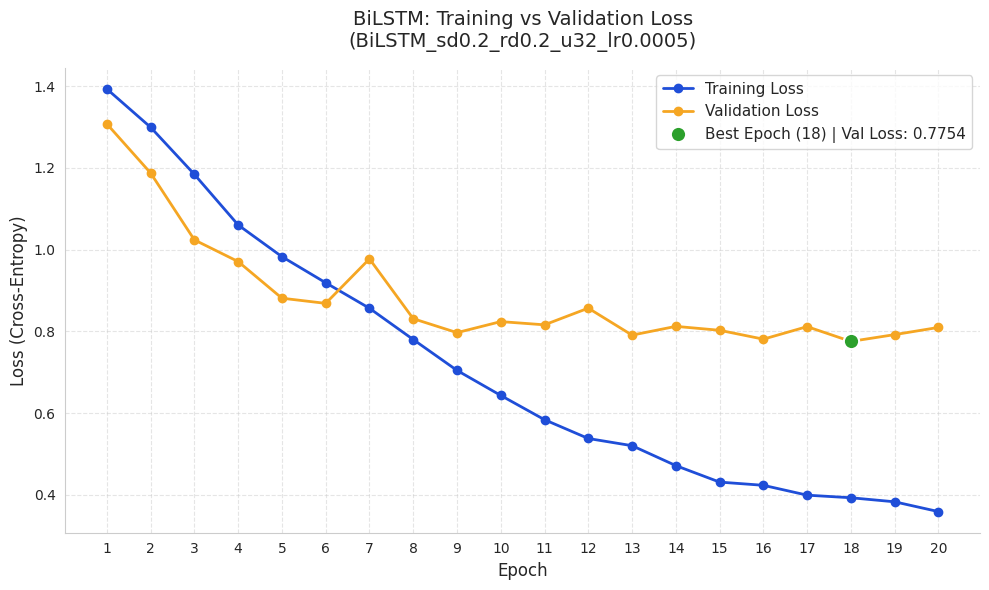

In [ ]:
history_path = os.path.join(BILSTM_RES, 'all_models_history.json')
model_name = "BiLSTM_sd0.2_rd0.2_u32_lr0.0005"   # best full-trained model

with open(history_path, 'r') as f:
    all_histories = json.load(f)

if model_name not in all_histories:
    print(f"Error: '{model_name}' not found. Available: {list(all_histories.keys())}")
else:
    history = all_histories[model_name]
    loss     = history['loss']
    val_loss = history['val_loss']
    epochs   = range(1, len(loss) + 1)

    best_epoch    = val_loss.index(min(val_loss)) + 1
    best_val_loss = min(val_loss)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    plt.plot(epochs, loss, color='#1f4ed8', marker='o', linewidth=2,
             markersize=6, label='Training Loss')
    plt.plot(epochs, val_loss, color='#f5a623', marker='o', linewidth=2,
             markersize=6, label='Validation Loss')

    # Early-stopping checkpoint
    plt.plot(best_epoch, best_val_loss, 'o', color='#2ca02c', markersize=11,
             markeredgecolor='white', markeredgewidth=1.5, zorder=5,
             label=f'Best Epoch ({best_epoch}) | Val Loss: {best_val_loss:.4f}')

    plt.title(f'BiLSTM: Training vs Validation Loss\n({model_name})', fontsize=14, pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
    plt.xticks(list(epochs))
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()

The learning curve gives a clear picture of the training dynamics for the selected model.
Through roughly the first six epochs, training and validation loss decrease together (with
validation slightly lower early on), indicating that the model is learning generalizable
features rather than memorizing the training data.

From around epoch 7 onward, after a brief spike in validation loss, the two curves begin
to diverge: training loss continues to fall steadily toward 0.36, while validation loss
flattens in the 0.78–0.86 range and oscillates mildly. This widening gap is the
characteristic signature of overfitting: the model keeps fitting the training set more
closely, but these additional gains no longer transfer to unseen data.

The training callbacks limit the impact of this behaviour. The `ReduceLROnPlateau`
scheduler lowers the learning rate when the validation loss stops improving, which reduces
the oscillations and helps the optimizer settle into a flatter region of the loss surface.
EarlyStopping, configured with `restore_best_weights=True`, then restores the weights from
**epoch 18**, the point of minimum validation loss (0.7754), so that the final model
corresponds to the best-generalizing checkpoint rather than the later, more overfit epochs.
Since the 20-epoch cap was reached before the patience threshold triggered, training ran to
the full schedule, and the best-weight restoration is what ensures the saved model is taken
from epoch 18.

### **5.4 Test Evaluation**

To definitively validate the generalization capabilities of our models, we evaluated the four final candidate architectures on the unseen Test Set, comprising 994 carefully stratified samples.

Test Set Evaluation (994 samples) | classes: ['Conspiratorial', 'Critical/Skeptical', 'Enthusiastic', 'Neutral']

Loading and testing: BiLSTM_sd0.2_rd0.4_u32_lr0.001
---------------------------------------------------------------------------


Macro F1: 0.6401

                    precision    recall  f1-score   support

    Conspiratorial       0.47      0.54      0.51        85
Critical/Skeptical       0.44      0.53      0.48        98
      Enthusiastic       0.81      0.82      0.82       429
           Neutral       0.79      0.72      0.75       382

          accuracy                           0.73       994
         macro avg       0.63      0.65      0.64       994
      weighted avg       0.74      0.73      0.73       994



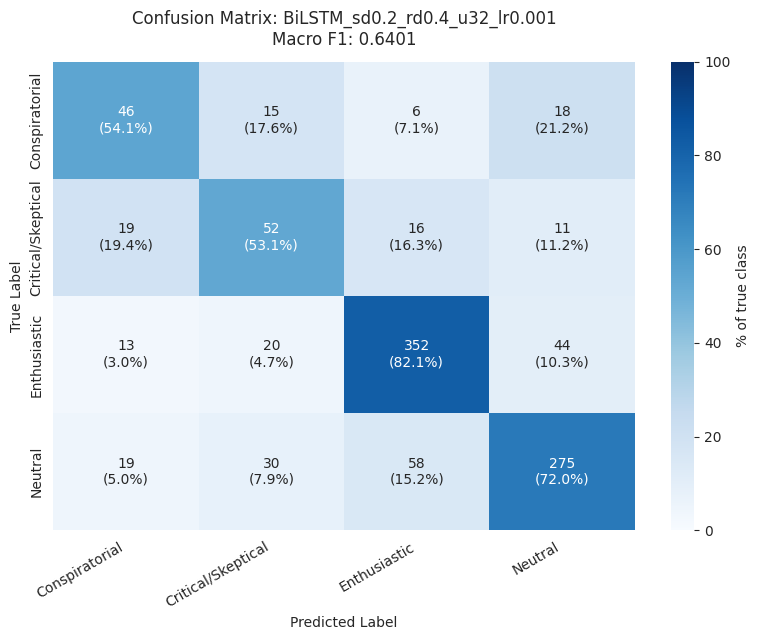


Loading and testing: BiLSTM_sd0.2_rd0.4_u16_lr0.001
---------------------------------------------------------------------------


Macro F1: 0.6238

                    precision    recall  f1-score   support

    Conspiratorial       0.53      0.49      0.51        85
Critical/Skeptical       0.40      0.64      0.49        98
      Enthusiastic       0.75      0.79      0.77       429
           Neutral       0.82      0.65      0.72       382

          accuracy                           0.70       994
         macro avg       0.62      0.64      0.62       994
      weighted avg       0.72      0.70      0.70       994



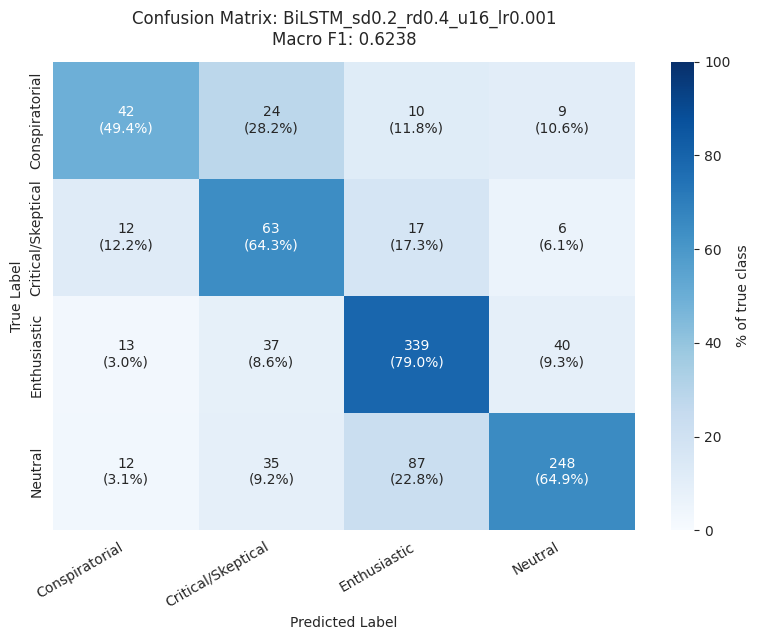


Loading and testing: BiLSTM_sd0.2_rd0.4_u32_lr0.0005
---------------------------------------------------------------------------
Macro F1: 0.6433

                    precision    recall  f1-score   support

    Conspiratorial       0.43      0.64      0.51        85
Critical/Skeptical       0.53      0.44      0.48        98
      Enthusiastic       0.79      0.85      0.82       429
           Neutral       0.82      0.70      0.76       382

          accuracy                           0.74       994
         macro avg       0.64      0.66      0.64       994
      weighted avg       0.75      0.74      0.74       994



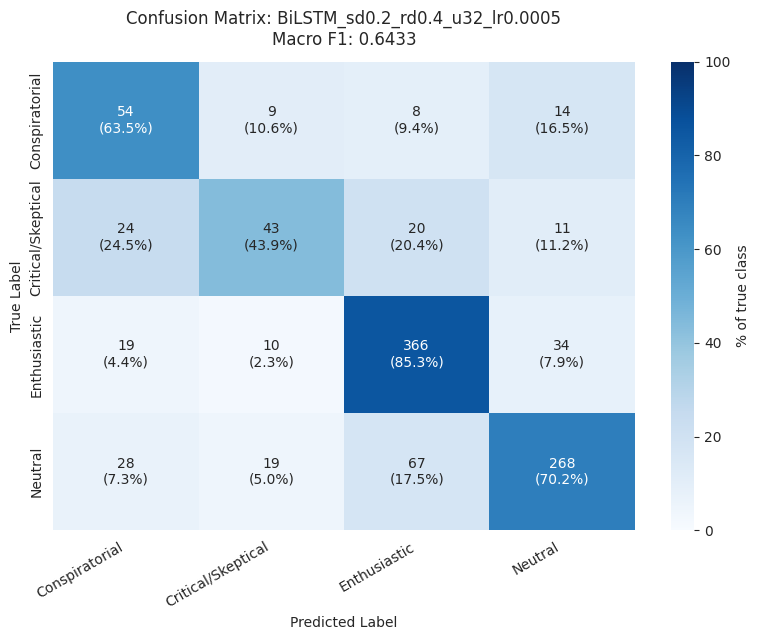


Loading and testing: BiLSTM_sd0.2_rd0.2_u32_lr0.0005
---------------------------------------------------------------------------


Macro F1: 0.6598

                    precision    recall  f1-score   support

    Conspiratorial       0.59      0.52      0.55        85
Critical/Skeptical       0.45      0.61      0.52        98
      Enthusiastic       0.80      0.82      0.81       429
           Neutral       0.80      0.73      0.76       382

          accuracy                           0.74       994
         macro avg       0.66      0.67      0.66       994
      weighted avg       0.75      0.74      0.74       994



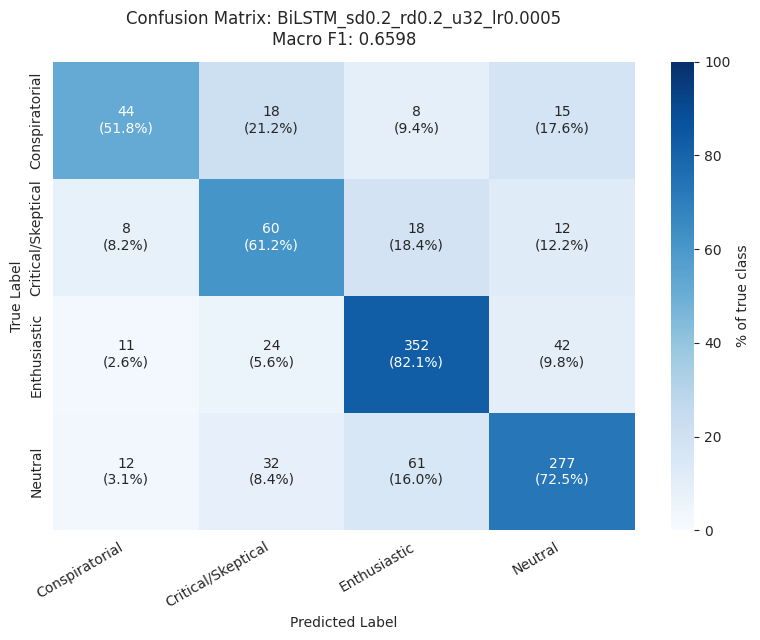

Evaluation complete for all 4 models.


In [ ]:
target_names = list(label_encoder.classes_)
all_eval_results = {}

print("=" * 75)
print(f"Test Set Evaluation ({len(X_test_pad)} samples) | classes: {target_names}")
print("=" * 75)

for _, row in candidates.iterrows():
    model_name = (f"BiLSTM_sd{row['spatial_dropout']}_rd{row['recurrent_dropout']}"
                  f"_u{int(row['lstm_units'])}_lr{row['learning_rate']}")
    h5_path = os.path.join(BILSTM_DIR, f"{model_name}.h5")

    print(f"\nLoading and testing: {model_name}")
    print("-" * 75)
    model = load_model(h5_path)

    y_pred_probs   = model.predict(X_test_pad, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    if model_name == "BiLSTM_sd0.2_rd0.2_u32_lr0.0005":
        np.save(os.path.join(BILSTM_RES, 'probs_bilstm.npy'), y_pred_probs)

    macro_f1 = f1_score(y_test_encoded, y_pred_classes, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test_encoded, y_pred_classes)
    print(f"Macro F1: {macro_f1:.4f}\n")

    print(classification_report(y_test_encoded, y_pred_classes,
                                target_names=target_names, zero_division=0))

    report_dict = classification_report(y_test_encoded, y_pred_classes,
                                        target_names=target_names,
                                        output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test_encoded, y_pred_classes)

    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    annot = np.empty_like(cm).astype(str)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

    plt.figure(figsize=(8, 6.5))
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                vmin=0, vmax=100, cbar_kws={'label': '% of true class'})
    plt.title(f'Confusion Matrix: {model_name}\nMacro F1: {macro_f1:.4f}', pad=12)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    all_eval_results[model_name] = {
        'model_name': model_name,
        'macro_f1': round(float(macro_f1), 4),
        'accuracy': round(float(accuracy), 4),
        'class_names': target_names,
        'confusion_matrix': cm.tolist(),
        'per_class_metrics': {
            cls: {'precision': round(report_dict[cls]['precision'], 4),
                  'recall': round(report_dict[cls]['recall'], 4),
                  'f1_score': round(report_dict[cls]['f1-score'], 4),
                  'support': int(report_dict[cls]['support'])}
            for cls in target_names}
    }

print("=" * 75)
print("Evaluation complete for all 4 models.")

An initial overview of the first three configurations reveals a consistent pattern. While they achieve respectable overall accuracies (around 70-73%), their performance is heavily anchored by the majority classes. Models 1, 2, and 3 successfully identify *Enthusiastic* and *Neutral* tweets with F1-scores generally exceeding 0.75. However, they struggle to balance precision and recall on the minority classes. Depending on the specific dropout rates, these models either severely over-predict the rare classes (yielding high recall but very poor precision, such as Model 2's 0.40 precision on Critical tweets) or fail to capture the nuances of the fringe narratives entirely.

The best configuration (`BiLSTM_sd0.2_rd0.2_u32_lr0.0005`) reaches a **macro F1** of **0.6598**. As expected, performance is
strongest on the majority classes, *Enthusiastic* (F1 0.81, 80.7% recall) and
*Neutral* (F1 0.76, 69.6% recall), where there is ample training data. The confusion matrix confirms these are well separated: the large majority of their tweets fall on the diagonal.

On the minority classes the picture is more mixed, and the confusion matrix shows exactly
where the difficulty lies. *Conspiratorial* reaches an F1 of 0.55 (precision 0.59,
recall 0.52): of its 85 tweets, 62 (72.9%) are correctly identified, but 12 leak into
*Critical/Skeptical* and 10 into *Neutral*. *Critical/Skeptical* reaches an F1 of 0.52
(precision 0.45, recall 0.61): the matrix shows its main confusion is with *Conspiratorial*
(17 tweets, 17.3%), the neighbouring skeptical class.

The clearest pattern is the mutual confusion between the two minority classes: 14.1%
of *Conspiratorial* tweets are predicted as *Critical/Skeptical*, and 17.3% of
Critical/Skeptical* tweets as *Conspiratorial*. This directly confirms the vocabulary
overlap identified in the `02_exploratory_data_analysis`, both classes share a skeptical register,
and the model cannot reliably separate criticism of the mission from denial of it. A
secondary source of error is the *Neutral* class absorbing minority tweets (39 *Conspiratorial*-predicted, 34 *Critical*-predicted come from true *Neutral* tweets), reflecting the factual,
news-like framing many minority tweets adopt.

Overall, the combination of pre-trained GloVe embeddings, class weighting, and the tuned
BiLSTM learns the majority classes well and achieves a fair balance on the minority
classes, but the *Conspiratorial–Critical* boundary remains the central difficulty.

### **5.5 Qualitative Analysis on Test Evaluation**

To gain deeper insights into the network's limitations, we must perform a qualitative error analysis, focusing exclusively on the most challenging and historically underrepresented categories: *Critical/Skeptical* and *Conspiratorial*.

WE filter and inspect the specific tweets where the true label diverges from the model's prediction, we can identify exactly which syntactic structures, subtle ironies, or specific out-of-vocabulary contexts the Bidirectional LSTM failed to decode.



In [ ]:
decoded_texts = tokenizer.sequences_to_texts(X_test_pad)

conspiratorial_idx = label_encoder.transform(['Conspiratorial'])[0]
critical_idx       = label_encoder.transform(['Critical/Skeptical'])[0]
minority_classes   = [conspiratorial_idx, critical_idx]

misclassified_indices = np.where((y_test_encoded != y_pred_classes) &
                                 (np.isin(y_test_encoded, minority_classes)))[0]

print("=" * 85)
print(f"QUALITATIVE ERROR ANALYSIS: {len(misclassified_indices)} misclassified minority samples.")
print("=" * 85 + "\n")

def get_original(idx):
    try:
        return X_test.iloc[idx]
    except AttributeError:
        return X_test[idx]

error_analysis_results = []
for idx in misclassified_indices:
    error_analysis_results.append({
        "test_index": int(idx),
        "true_label": label_encoder.inverse_transform([y_test_encoded[idx]])[0],
        "pred_label": label_encoder.inverse_transform([y_pred_classes[idx]])[0],
        "original_text": get_original(idx),
        "model_input_text": decoded_texts[idx]
    })

NUM_SAMPLES_TO_SHOW = 15
for i, e in enumerate(error_analysis_results[:NUM_SAMPLES_TO_SHOW]):
    print(f"Sample {i+1}")
    print(f"TRUE LABEL:   [{e['true_label']}]")
    print(f"PREDICTION:   [{e['pred_label']}]")
    print(f"ORIGINAL:     \"{e['original_text']}\"")
    print(f"MODEL INPUT:  \"{e['model_input_text']}\"")
    print("-" * 85)

QUALITATIVE ERROR ANALYSIS: 79 misclassified minority samples.

Sample 1
TRUE LABEL:   [Conspiratorial]
PREDICTION:   [Enthusiastic]
ORIGINAL:     "Polymarket I'm guessing ArtemisII will make an astounding 'discovery'. sarcasm"
MODEL INPUT:  "polymarket i'm guessing artemisii will make an astounding <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>"
-------------------------------------------------------------------------------------
Sample 2
TRUE LABEL:   [Critical/Skeptical]
PREDICTION:   [Enthusiastic]
ORIGINAL:     "We can put people around the moon but we can't even figure out how to talk to them? What kind of now rung operation is NASA running? rocket full moon woman astronaut astronaut medium-dark skin tone astronaut astr

The extraction of misclassified minority samples exposes two distinct sources of error in the BiLSTM, which the side-by-side comparison of the original tweet and the model's actual input (after tokenization) makes possible to separate.

* **1. Errors caused by vocabulary loss (out-of-vocabulary tokens).**
In several cases the model failed not because it misunderstood the sentence, but because the decisive word was never available to it. The word-level tokenizer replaces any term outside its fixed vocabulary with an `<OOV>` token, and for short tweets this can remove exactly the cue that determines the label. **Sample 1** is the clearest example: the
original tweet: *"...will make an astounding 'discovery'. sarcasm"*, was labelled *Conspiratorial* precisely because of the words "discovery" and "sarcasm". Both became `<OOV>` in the model input, leaving only the adjective "astounding"; deprived of its ironic anchor, the model predicted *Enthusiastic*. **Sample 12** follows the same pattern: the critical word "brilliance" is lost to `<OOV>`, and the remaining space-related terms ("technology", "moon", "nasa") push the prediction toward *Enthusiastic*. These are limitations of the input representation, not of the model's reasoning.

* **2. Errors of genuine semantic interpretation.**
Other errors occur even when the relevant words are present, revealing the model's difficulty with structure and tone. In **Sample 13** ("the artemis 2 stuff is cool and all but who really cares"), every word is in-vocabulary, yet the positive term "cool" outweighs the dismissive clause "but who really cares", and the tweet is misread as *Enthusiastic*. The BiLSTM struggles to weigh a structural negation against a strong positive keyword.

* **3. Overlap between the two minority classes.**
A third pattern is the confusion between *Critical/Skeptical* and *Conspiratorial*, the two classes the exploratory analysis already identified as lexically close. In **Sample 9**
("is this a con?") and **Sample 15** ("believe nothing about the launch"), tweets labelled *Critical/Skeptical* are predicted *Conspiratorial*: expressions such as "con" or "believe nothing" act as strong cues for the conspiratorial category, leading the model to read harsh criticism of the mission's coverage as outright denial. This directly confirms the
vocabulary overlap observed in the bigram and word-cloud analyses.

Taken together, these errors reflect the limits of a word-level recurrent model on short, informal text: a fixed vocabulary that discards rare but decisive words, and a limited ability to resolve negation, irony, and the fine boundary between criticism and denial.


> **Note**: The tokenizer, label encoder, and preprocessing configuration are inputs to this notebook: by default they are loaded from the saved files in `models/`, because the trained models depend on these exact objects. This cell therefore does **not** overwrite them under normal use. It re-saves them only when `FORCE_RETRAIN = True`, i.e. after a fresh retraining run that rebuilds the tokenizer and encoder, so that the saved artifacts stay consistent with the newly trained models.

In [ ]:
if FORCE_RETRAIN:
    # Regenerate the preprocessing artifacts after a fresh retrain
    with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'wb') as f:
        pickle.dump(label_encoder, f)
    with open(os.path.join(MODELS_DIR, 'tokenizer.pkl'), 'wb') as f:
        pickle.dump(tokenizer, f)
    preprocessing_config = {
        'vocab_size': VOCAB_SIZE, 'max_len': MAX_LEN, 'embed_dim': EMBED_DIM,
        'contraction_map': CONTRACTION_MAP,
        'apostrophe_variants': ['\u0027','\u2019','\u2018','\u0060','\u00B4','\u02BC']
    }
    with open(os.path.join(MODELS_DIR, 'preprocessing_config.json'), 'w') as f:
        json.dump(preprocessing_config, f, indent=2)
    print("Preprocessing artifacts re-saved (FORCE_RETRAIN).")
else:
    print("Preprocessing artifacts already present in models/ — not overwriting.")

Preprocessing artifacts already present in models/ — not overwriting.


## **6. ULMFiT**

### **6.1 Introduction**

The previous stage of this project established a baseline using a Bidirectional-LSTM whose embedding layer was initialised with pre-trained GloVe Twitter vectors. While that approach already incorporates a limited form of transfer (the word embeddings carry general knowledge), the recurrent network itself is trained entirely from scratch on our labelled Artemis corpus. This is the classical paradigm of neural NLP before 2018: pre-trained word vectors plus a task-specific model learned from zero.

**ULMFiT** (Universal Language Model Fine-Tuning), introduced by Howard and Ruder in 2018, marks the conceptual turning point between that classical paradigm and the modern Transformer era. It was the first method to demonstrate that an entire language model, not just its embeddings, could be pre-trained on a large general corpus and then fine-tuned on a downstream task.

For this reason ULMFiT is included here as a deliberate **bridge**: it shares the recurrent foundation of the BiLSTM while introducing the pre-train / adapt / fine-tune workflow that defines the Transformer models evaluated in the next stage.

####  **6.1.1 Theoretical Foundations**

ULMFiT rests on three innovations that together make fine-tuning a pre-trained language model stable and effective.

1. **Discriminative fine-tuning**: Different layers of the network encode different levels of linguistic abstraction, from low-level syntax in the early layers to task-specific patterns in the later ones. Rather than applying a single learning rate to the whole network, ULMFiT assigns progressively smaller learning rates to the deeper, more general layers, so that the broad knowledge acquired during pre-training is preserved while the upper layers adapt more freely to the target task. In our implementation this is expressed through the `slice(...)` learning-rate ranges, where the lower bound (applied to the earliest layers) is much smaller than the upper bound (applied to the last layers).

2. **Slanted triangular learning rates**: Instead of a constant or monotonically decaying learning rate, ULMFiT briefly increases the learning rate at the start of training and then decays it for the remainder. This warm-up-then-decay shape helps the model first move quickly towards a good region of the loss surface and then settle into it. In fastai this behaviour is provided automatically by `fit_one_cycle`, which is why every training call in our pipeline uses it.

3. **Gradual unfreezing**: Fine-tuning all layers at once tends to destroy the pre-trained representations, a phenomenon known as catastrophic forgetting. ULMFiT instead unfreezes the network one layer group at a time, starting from the classifier head and progressively releasing deeper layers. This is implemented explicitly in our code through the sequence of `freeze_to(-2)`, `freeze_to(-3)` and finally `unfreeze()` calls.

#### **6.1.2 Pipeline Structure**

The ULMFiT workflow is organised into three stages, the last of which is split into four progressive phases.

##### **Stage 1: Language Model Fine-Tuning.**

A pre-trained AWD-LSTM language model (originally trained on a large English corpus) is adapted to our domain by training it to predict the next token on the Artemis tweet corpus, in a self-supervised manner that requires no labels. This step teaches the model the specific vocabulary, hashtags and writing style of our tweets, directly addressing the out-of-vocabulary problem encountered with GloVe. The language model is first trained with its body frozen for one epoch, then unfrozen and trained for three further epochs, after which its encoder (the recurrent body, without the next-word prediction head) is saved for reuse.

##### **Stage 2: Classifier Construction.**

A classification head is attached to the domain-adapted encoder. The classifier data loaders are built using exactly the same vocabulary as the language model, ensuring that the indices learned during Stage 1 remain valid. The saved encoder is then loaded into the classifier so that all the domain knowledge acquired in Stage 1 is carried over.

##### **Stage 3: Gradual Unfreezing and Classification Fine-Tuning**

The classifier is fine-tuned in four phases. The first phase trains only the classifier head while the encoder remains frozen. The second and third phases progressively unfreeze the last two and last three layer groups respectively, each with discriminative learning rates. The final phase unfreezes the entire network and trains it with the smallest learning-rate range. This staged release is what allows the model to specialise for sentiment classification without discarding the language understanding built up in the earlier stages.

#### **6.1.3 Hyperparameters Choice**

The hyperparameter choices were made to keep the experiment both faithful to the original ULMFiT recipe and consistent with the decisions taken for the BiLSTM, so that the two models remain comparable.

The global dropout multiplier `drop_mult` is the single scalar through which fastai scales all five internal dropout types of the AWD-LSTM at once; it is the conceptual counterpart of the `spatial_dropout` and `recurrent_dropout` parameters tuned for the BiLSTM. For the language-model stage it was set to 0.3, and for the classifier stage it was raised to 0.5. This higher value applies stronger regularisation than any configuration explored for the BiLSTM, and was chosen deliberately in response to the persistent overfitting observed throughout the project, where training loss consistently fell faster than validation loss. Because the classifier inherits a large number of pre-trained parameters, more aggressive dropout is warranted to prevent it from overfitting to the comparatively small labelled corpus.

The learning rates follow the discriminative scheme of the original paper. The language model uses 2e-2 while frozen and 2e-3 once unfrozen. The classifier head is trained at 2e-2, after which each unfreezing phase uses a `slice` whose bounds decrease as more layers are released,  from `slice(1e-2/2.6**4, 1e-2)` for the last two layers, to `slice(5e-3/2.6**4, 5e-3)` for the last three, to `slice(1e-3/2.6**4, 1e-3)` for the fully unfrozen network. The factor 2.6 between consecutive layer groups is the value recommended in the ULMFiT paper. This adaptive, per-layer scheduling is conceptually richer than the single learning rate searched for the BiLSTM, and it removes much of the sensitivity to the initial learning rate that was a concern during the BiLSTM grid search.

To preserve methodological consistency, the same class imbalance handling was used as for the BiLSTM. The balanced class weights computed earlier with scikit-learn were converted into a tensor and passed into a weighted cross-entropy loss, so that both architectures are optimised under the same imbalance-aware objective. This ensures that the macro F1 scores of the BiLSTM and ULMFiT are directly comparable, since the only substantive difference between the two experiments is the model architecture and the transfer-learning procedure, not the data, the splits, the loss, or the evaluation metric.

#### **6.1.4 Evaluation**

Consistent with the rest of the project, the model is monitored during training through validation loss and macro F1, while the final, unbiased assessment is performed on the held-out test set, the same split used to evaluate the BiLSTM. Macro F1 is retained as the primary metric because it weights all four sentiment classes equally and therefore reflects performance on the minority classes (*Conspiratorial* and *Critical/Skeptical*) rather than being dominated by the majority *Enthusiastic* and *Neutral* classes.

> The ULMFiT pipeline below fine-tunes the AWD-LSTM language model (Stage 1) and
then trains the classifier with gradual unfreezing (Stage 3). The training was
executed once on a GPU runtime; the saved model and metrics in `models/ulmfit/`
and `results/ulmfit/` are the artifacts produced by that run.

> The output shown below is a captured image of the original training run. fastai
renders its training progress as live, interactive HTML tables (per-epoch loss,
perplexity, and F1 with dynamic progress bars) that cannot be reproduced
statically from saved logs, which is why it is included as an image rather than
as regenerable cell output. Anyone who sets `FORCE_RETRAIN = True` and runs the
training cell on a GPU runtime will obtain an equivalent live output, the same
sequence of Stage 1 and Stage 3 tables shown in the image, with values close (but
not identical, due to GPU non-determinism) to those captured here. The final
per-epoch history is also persisted in `ulmfit_training_history.json` and
visualised in the learning-curve plot below.

In [ ]:
ulmfit_history_path = os.path.join(ULMFIT_RES, 'ulmfit_training_history.json')

if os.path.exists(ulmfit_history_path) and not FORCE_RETRAIN:
    with open(ulmfit_history_path, 'r') as f:
        full_history = json.load(f)
    print("ULMFiT training history loaded from saved file.")
    print(f"  Epochs recorded: {len(full_history['train_loss'])}")
else:

    set_seed(SEED)
    os.makedirs(ULMFIT_RES, exist_ok=True)
    os.makedirs(ULMFIT_MODEL_DIR, exist_ok=True)

    df_train  = pd.DataFrame({'text': X_train, 'label': y_train_encoded, 'is_valid': False})
    df_val    = pd.DataFrame({'text': X_val,   'label': y_val_encoded,   'is_valid': True})
    df_ulmfit = pd.concat([df_train, df_val], ignore_index=True)

    print("--- Stage 1: Language Model fine-tuning ---")
    dls_lm = TextDataLoaders.from_df(df_ulmfit, text_col='text', is_lm=True, valid_col='is_valid')
    learn_lm = language_model_learner(dls_lm, AWD_LSTM, drop_mult=0.3,
                                      metrics=[accuracy, Perplexity()])
    learn_lm.fit_one_cycle(1, 2e-2)
    learn_lm.unfreeze()
    learn_lm.fit_one_cycle(3, 2e-3)
    learn_lm.save_encoder('artemis_lm_encoder')

    print("\n--- Stage 2: Classifier setup ---")
    dls_clas = TextDataLoaders.from_df(df_ulmfit, text_col='text', label_col='label',
                                       valid_col='is_valid', text_vocab=dls_lm.vocab)
    device = default_device()
    tensor_weights = torch.tensor(weights, dtype=torch.float32).to(device)
    weighted_loss  = CrossEntropyLossFlat(weight=tensor_weights)
    macro_f1 = F1Score(average='macro')

    learn_clas = text_classifier_learner(dls_clas, AWD_LSTM, drop_mult=0.5,
                                          metrics=[macro_f1], loss_func=weighted_loss)
    learn_clas = learn_clas.load_encoder('artemis_lm_encoder')

    print("\n--- Stage 3: Gradual unfreezing ---")
    csv_path = os.path.join(ULMFIT_RES, 'ulmfit_history_raw.csv')
    learn_clas.fit_one_cycle(1, 2e-2, cbs=CSVLogger(fname=csv_path, append=False))
    learn_clas.freeze_to(-2)
    learn_clas.fit_one_cycle(1, slice(1e-2/(2.6**4), 1e-2), cbs=CSVLogger(fname=csv_path, append=True))
    learn_clas.freeze_to(-3)
    learn_clas.fit_one_cycle(1, slice(5e-3/(2.6**4), 5e-3), cbs=CSVLogger(fname=csv_path, append=True))
    learn_clas.unfreeze()
    learn_clas.fit_one_cycle(2, slice(1e-3/(2.6**4), 1e-3), cbs=CSVLogger(fname=csv_path, append=True))
    print("Training completed.")

    hist_df = pd.read_csv(csv_path)
    hist_df = hist_df[hist_df['train_loss'] != 'train_loss'].reset_index(drop=True)
    full_history = {
        'train_loss': hist_df['train_loss'].astype(float).tolist(),
        'valid_loss': hist_df['valid_loss'].astype(float).tolist(),
        'macro_f1':   hist_df['f1_score'].astype(float).tolist()
    }
    with open(ulmfit_history_path, 'w') as f:
        json.dump(full_history, f, indent=4)
    learn_clas.export(os.path.join(ULMFIT_MODEL_DIR, 'ulmfit_classifier.pkl'))
    if os.path.exists(csv_path):
        os.remove(csv_path)
    print("ULMFiT artifacts regenerated.")

ULMFiT training history loaded from saved file.
  Epochs recorded: 5


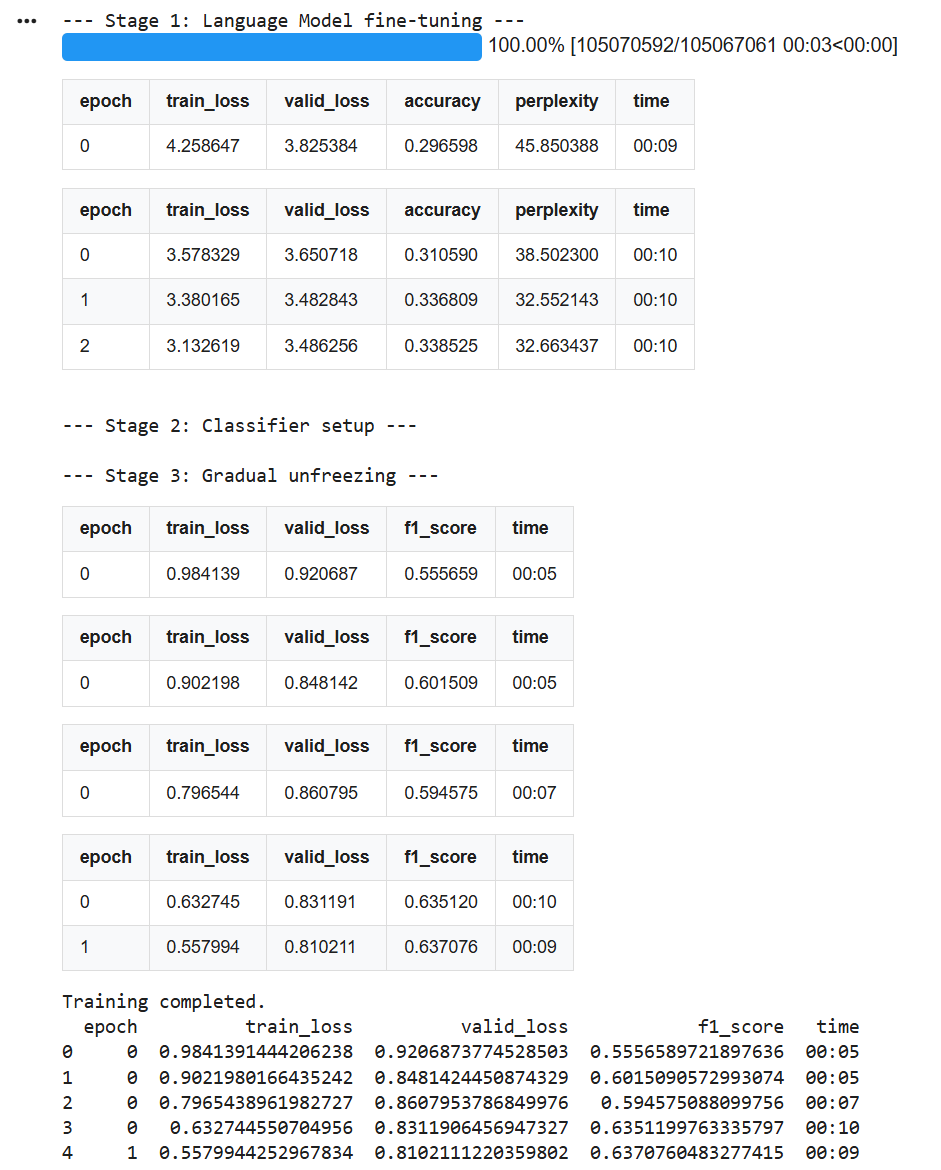

In [ ]:
from IPython.display import Image, display
img_path = os.path.join(ULMFIT_FIG, 'ulmfit_training_output.png')
display(Image(filename=img_path))

### **6.2 Training Results**

The training history reflects the four-phase gradual unfreezing schedule (1 + 1 + 1 + 2 epochs), for a total of five classifier epochs. The training loss decreased steadily from 0.984 to 0.558, while the validation loss declined more gradually from 0.921 to 0.810. For most of training the two losses stayed close, indicating controlled learning rather than rapid memorisation. Towards the final epochs, however, the training loss began to fall noticeably faster than the validation loss (a gap of about 0.25 by the last epoch), signalling the early onset of overfitting. This controlled trajectory is
the effect of the regularisation strategy: the global dropout multiplier (`drop_mult = 0.5`), discriminative learning rates, and gradual unfreezing, which prevent the pre-trained representations from being overwritten too quickly.

In the first epoch the validation loss is actually lower than the training loss. This is expected rather than anomalous: dropout is active during the training pass but disabled at validation, so the model is evaluated in a "cleaner" configuration. The temporary rise in validation loss at the third epoch (index 2) coincides with the phase in which a further
layer group was unfrozen (`freeze_to(-3)`); releasing new layers briefly perturbs the optimisation before the loss resumes its descent, a normal artefact of gradual unfreezing.

Overall, the validation macro F1 rose from 0.556 to 0.637 across the five epochs, with the lowest **validation loss (0.810)** reached at the final epoch, where the **macro F1** is **0.637**.
This final epoch therefore provides the checkpoint used as the trained ULMFiT classifier. The final unfreezing phase was limited to two epochs based on preliminary experimentation: extending it further caused the validation loss to flatten and then rise while the training loss kept falling, a clear sign of overfitting that was not compensated by any meaningful
gain in macro F1.
The 1 + 1 + 1 + 2 schedule therefore represents the point at which the
model reaches its best generalisation before overfitting takes hold.

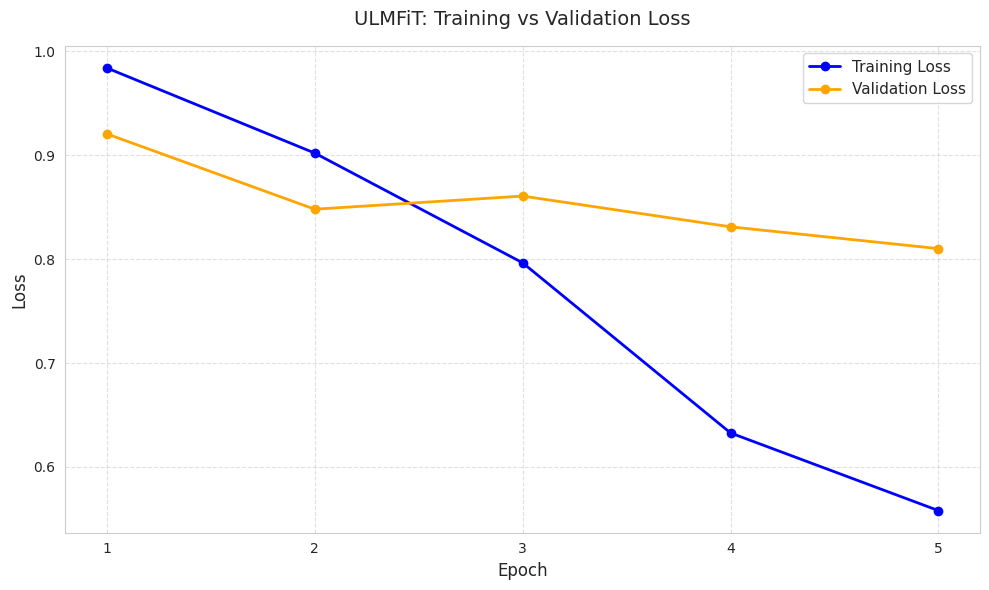

In [ ]:
epochs = range(1, len(full_history['train_loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, full_history['train_loss'], color='blue', marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, full_history['valid_loss'], color='orange', marker='o', linewidth=2, label='Validation Loss')
plt.title('ULMFiT: Training vs Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12); plt.ylabel('Loss', fontsize=12)
plt.xticks(list(epochs)); plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

### **6.3 Test Evaluation**

Test Set Evaluation


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")



ULMFiT — Test Macro F1: 0.6653

                    precision    recall  f1-score   support

    Conspiratorial       0.43      0.73      0.54        85
Critical/Skeptical       0.44      0.62      0.52        98
      Enthusiastic       0.86      0.81      0.83       429
           Neutral       0.85      0.70      0.77       382

          accuracy                           0.74       994
         macro avg       0.65      0.71      0.67       994
      weighted avg       0.78      0.74      0.75       994



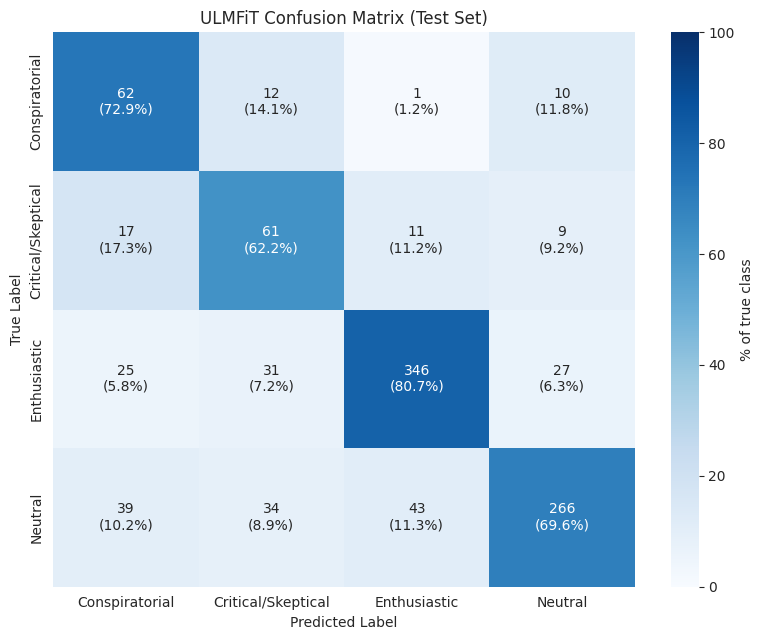

In [ ]:
ulmfit_pkl_path = os.path.join(ULMFIT_MODEL_DIR, 'ulmfit_classifier.pkl')

if os.path.exists(ulmfit_pkl_path):
    # ---- LIVE INFERENCE (pkl available) ----
    print("Test Set Evaluation")
    learn_clas = load_learner(ulmfit_pkl_path)
    df_test = pd.DataFrame({'text': X_test, 'label': y_test_encoded})
    test_dl = learn_clas.dls.test_dl(df_test, with_labels=True)
    preds, targets = learn_clas.get_preds(dl=test_dl)
    ulmfit_probs = preds.numpy().astype(np.float32)
    predictions, targets = np.argmax(ulmfit_probs, axis=-1), targets.numpy()
    np.save(os.path.join(ULMFIT_RES, 'probs_ulmfit.npy'), ulmfit_probs)
    test_f1 = f1_score(targets, predictions, average='macro', zero_division=0)
    print(f"\nULMFiT — Test Macro F1: {test_f1:.4f}\n")
    print(classification_report(targets, predictions, target_names=label_encoder.classes_, zero_division=0))
    cm = confusion_matrix(targets, predictions)
    class_names = list(label_encoder.classes_)
else:
    # ---- FALLBACK: display saved results (pkl not downloaded) ----
    print("ULMFiT model not found locally — displaying saved evaluation results.")
    print("(Download ulmfit_classifier.pkl into models/ulmfit/ to run live inference.)")
    with open(os.path.join(ULMFIT_RES, 'ulmfit_summary.json')) as f:
        s = json.load(f)
    test_f1 = s['test_macro_f1']
    cm = np.array(s['confusion_matrix'])
    class_names = s['class_names']
    print(f"\nULMFiT — Test Macro F1: {test_f1:.4f}\n")
    print(pd.DataFrame(s['per_class_metrics']).T[['precision','recall','f1_score','support']].to_string())

cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
annot = np.empty_like(cm).astype(str)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=100, cbar_kws={'label': '% of true class'})
plt.title('ULMFiT Confusion Matrix (Test Set)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

On the held-out test set (the same split used for the BiLSTM), ULMFiT reached a **macro F1 of 0.665**, essentially level with the BiLSTM's 0.660. The half-point gap falls within normal run-to-run variation, so the two models perform comparably overall, but the confusion matrices show they reach that result through different trade-offs.

The clearest difference is on the *Conspiratorial* class. ULMFiT recovers far more of these tweets than the BiLSTM: its recall rises from 51.8% (44/85) to **72.9%** (62/85). However, this broader reach comes at the cost of precision, which falls from 0.59 (BiLSTM) to **0.43** (ULMFiT): ULMFiT flags conspiratorial content more aggressively, pulling in tweets
from other classes (notably 39 true *Neutral* tweets, 10.2% of that class). The BiLSTM is the
more conservative of the two here: more precise, but missing nearly half of the actual
conspiratorial tweets.

On *Critical/Skeptical* the two models are essentially tied (recall 61.2% vs 62.2%, F1 0.52 for both), and on the majority classes the BiLSTM holds a slight edge (*Enthusiastic* recall
82.1% vs 80.7%, *Neutral* 72.5% vs 69.6%). ULMFiT's advantage is therefore concentrated almost entirely in its higher Conspiratorial recall, which roughly offsets its lower precision and leaves the two macro-F1 scores nearly equal.

Both models also share the same core weakness: the two minority classes leak into each other (e.g. 17.3% of *Critical/Skeptical* tweets predicted as *Conspiratorial* by ULMFiT, and 21.2%
of *Conspiratorial* predicted as *Critical/Skeptical* by the BiLSTM), confirming the vocabulary overlap identified in the `02_exploratory_data_analysis`, both classes are skeptical, and neither model
reliably separates criticism from denial.

Taken together, transfer learning with ULMFiT did not clearly outperform the from-scratch GloVe-BiLSTM on this small, domain-specific corpus: it redistributes errors (more
conspiratorial recall, less precision) rather than reducing them overall. The likely reason is
that the GloVe Twitter embeddings already encode much of the tweet-specific knowledge that
ULMFiT, pre-trained on Wikipedia, partly lacks. Both recurrent models settle around a macro F1 of roughly 0.66, a shared ceiling that motivates the next phase: whether attention-based Transformer architectures can push past it.

### **6.4 Comparative Qualitative Analysis of Predictions: ULMFiT vs. BiLSTM**

The macro-F1 scores tell us the two recurrent models perform almost equally, but not *whether* they succeed and fail on the same tweets. To examine this, we compare the BiLSTM and ULMFiT predictions tweet by tweet on the full test set and divide the samples into four
groups: those both models classify correctly, those both misclassify, those the BiLSTM gets
wrong but ULMFiT corrects, and those the BiLSTM gets right but ULMFiT breaks. The two disagreement groups are the most informative: they reveal whether transfer learning genuinely reduces errors or simply shifts them onto different tweets, and they expose the characteristic bias of each model. A few randomly sampled examples from each group are shown to illustrate the kinds of tweets that move in either direction.


In [ ]:
ulmfit_probs_path = os.path.join(ULMFIT_RES, 'probs_ulmfit.npy')

if 'ulmfit_probs' not in dir():
    ulmfit_probs = np.load(ulmfit_probs_path)

ulmfit_predictions = np.argmax(ulmfit_probs, axis=-1)
bilstm_predictions = y_pred_classes          # best BiLSTM, full test set
truth = y_test_encoded

bilstm_correct = bilstm_predictions == truth
ulmfit_correct = ulmfit_predictions == truth

both_correct  = np.where(bilstm_correct & ulmfit_correct)[0]
both_wrong    = np.where(~bilstm_correct & ~ulmfit_correct)[0]
ulmfit_fixes  = np.where(~bilstm_correct & ulmfit_correct)[0]   # BiLSTM wrong, ULMFiT right
ulmfit_breaks = np.where(bilstm_correct & ~ulmfit_correct)[0]   # BiLSTM right, ULMFiT wrong

print("=" * 85)
print("AGREEMENT ANALYSIS: BiLSTM vs ULMFiT on the full test set")
print("=" * 85)
print(f"Both correct      : {len(both_correct):>4}")
print(f"Both wrong        : {len(both_wrong):>4}")
print(f"ULMFiT fixes      : {len(ulmfit_fixes):>4}  (BiLSTM wrong, ULMFiT right)")
print(f"ULMFiT breaks     : {len(ulmfit_breaks):>4}  (BiLSTM right, ULMFiT wrong)")
print(f"Net change        : {len(ulmfit_fixes) - len(ulmfit_breaks):>+4}")
print("=" * 85 + "\n")

rng = np.random.default_rng(1308)

def show_examples(indices, title, n=6):
    n = min(n, len(indices))
    sampled = rng.choice(indices, size=n, replace=False)   # pesca casuale senza ripetizioni
    print(f"--- {title} (showing {n} random of {len(indices)}) ---\n")
    for k, idx in enumerate(sampled):
        t = label_encoder.inverse_transform([truth[idx]])[0]
        b = label_encoder.inverse_transform([bilstm_predictions[idx]])[0]
        u = label_encoder.inverse_transform([ulmfit_predictions[idx]])[0]
        try:
            text = X_test.iloc[idx]
        except AttributeError:
            text = X_test[idx]
        print(f"[{k+1}] TRUE: {t}")
        print(f"    BiLSTM: {b}   |   ULMFiT: {u}")
        print(f"    TEXT: \"{text}\"")
        print("-" * 85)
    print()

show_examples(ulmfit_fixes,  "ULMFiT FIXES (BiLSTM wrong, ULMFiT right)")
show_examples(ulmfit_breaks, "ULMFiT BREAKS (BiLSTM right, ULMFiT wrong)")

AGREEMENT ANALYSIS: BiLSTM vs ULMFiT on the full test set
Both correct      :  638
Both wrong        :  164
ULMFiT fixes      :   97  (BiLSTM wrong, ULMFiT right)
ULMFiT breaks     :   95  (BiLSTM right, ULMFiT wrong)
Net change        :   +2

--- ULMFiT FIXES (BiLSTM wrong, ULMFiT right) (showing 6 random of 97) ---

[1] TRUE: Enthusiastic
    BiLSTM: Conspiratorial   |   ULMFiT: Enthusiastic
    TEXT: "Let's make this a slightly longer post as it's important. Here's why today's successful conclusion of the Artemis 2 lunar mission is such a profound accomplishment. Up until a decade ago, the moon was a useless space rock. Until Indian and Japanese probes found ice. And NASA confirmed massive deposits of it later with ground penetrating orbital radar. Now, all of a sudden you have water, air and rocket fuel along with abundance of every single mineral imaginable. Whomever controls the moon by being first to stay & control the resources, controls the entire future of humanity in space. 

Comparing the two models tweet by tweet on the full test set makes the nature of their similarity precise. They agree on the large majority of cases, **638** both correct and **164** both wrong, leaving **192** tweets on which they disagree. Of these, ULMFiT corrects **97** errors made by the BiLSTM but introduces **95** new ones, for a net change of only +2 out of 994 samples.

This is the clearest explanation of why the two macro-F1 scores are almost identical (0.665 vs 0.660): ULMFiT does not reduce the overall number of errors, it redistributes them. The two models are of essentially equal quality and differ mainly in *which* tweets they misclassify.

The examples show that the two models have opposite biases. Among the cases ULMFiT fixes, many are tweets the BiLSTM read as the wrong class because of isolated keywords. For example, a critical complaint ("We can put people around the moon but we can't even figure out how to
talk to them? What kind of ... operation is NASA running?") was labelled *Enthusiastic* by the BiLSTM and correctly *Critical/Skeptical* by ULMFiT; a clearly positive tweet ("Launch of Artemis 2 some of the best ... I've seen in months") was misread as *Neutral* by the BiLSTM
and correctly *Enthusiastic* by ULMFiT. ULMFiT reads the sentence as a whole more reliably, recovering both critical and enthusiastic tweets that the BiLSTM mishandled.

Conversely, the cases ULMFiT breaks are dominated by genuinely *Enthusiastic* or *Neutral* tweets that ULMFiT pushes into the minority classes. Excited posts such as "im so insane about the artemis 2 mission omgg bcs wdym 4 people are currently behind the moon without any contact
with earth???" are misread by ULMFiT as *Conspiratorial*, and neutral statements such as "Just more coolness from the Artemis2 mission" become *Critical/Skeptical*. Where the BiLSTM tends to over-predict enthusiasm, ULMFiT tends to over-predict the minority/sceptical classes.

A recurring source of error for both models is figurative, quotation-laden, or punctuation-only text. The Seamus Heaney quotation ("Believe that a further shore is reachable from here...") and the near-empty "Matt Pinner .. .... ... The Artemis 2 landing." are misclassified by ULMFiT
even when the BiLSTM happens to get them right, illustrating how little reliable signal such tweets contain.

These opposite tendencies cancel out, which is why neither model gains a real advantage.

### **7. Partial Conclusions**

The two recurrent models examined, the from-scratch GloVe-BiLSTM and the
transfer-learning ULMFiT, reach almost identical performance, settling around a macro F1 of 0.66. The tweet-by-tweet comparison showed that this similarity is not superficial: beyond the 164 tweets that both models misclassify, each model fixes and breaks a comparable number of the remaining cases, so neither achieves a real advantage over the other. They differ in *which*
tweets they get wrong, not in *how many*.

Several factors explain this shared ceiling. The BiLSTM is limited by its fixed word-level vocabulary, which discards rare but decisive words as out-of-vocabulary tokens, and by its tendency to be swayed by isolated positive keywords. ULMFiT also uses a word-level tokenizer, but mitigates the vocabulary problem through its pre-trained AWD-LSTM language model and a larger, corpus-fitted vocabulary, and it reads context more globally; however,
it over-predicts the minority classes, mistaking enthusiasm or neutral reporting for criticism or denial. Both models share a deeper difficulty: separating the two minority classes, *Critical/Skeptical* and *Conspiratorial*, whose vocabularies overlap heavily, as already observed in the exploratory analysis.

It is also worth acknowledging that a portion of these errors does not stem from the models alone. Many of the hardest tweets are genuinely ambiguous, heavy sarcasm, figurative or quotation-laden language, irony, and posts with almost no classifiable content, where even a
human annotator would hesitate or disagree on the correct label. In these cases the boundary between sentiment classes is intrinsically blurred, and no model can be expected to resolve it with full confidence.

These observations define the goal of the next phase. The residual errors shared by both recurrent models, short, context-dependent, ambiguous
tweets where meaning depends on the sentence as a whole rather than on individual words, are
precisely the cases that attention-based Transformer architectures are designed to address.
Unlike the word-level tokenizers used by both recurrent models, Transformers rely on subword tokenization, which avoids most out-of-vocabulary loss, and their self-attention mechanism
captures long-range and bidirectional context directly.

The following notebook evaluates whether these properties allow
Transformer models to push past the 0.66 ceiling reached here, particularly on the difficult
minority and context-dependent tweets that the recurrent models could not reliably classify.